**Chapter 4 – Training Models**

_This notebook contains all the sample code and solutions to the exercises in chapter 4._

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/04_training_linear_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/04_training_linear_models.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

This project requires Python 3.7 or above:

In [388]:
import sys

assert sys.version_info >= (3, 7)

It also requires Scikit-Learn ≥ 1.0.1:

In [389]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

As we did in previous chapters, let's define the default font sizes to make the figures prettier:

In [390]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

And let's create the `images/training_linear_models` folder (if it doesn't already exist), and define the `save_fig()` function which is used through this notebook to save the figures in high-res for the book:

In [391]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "training_linear_models"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

---

# Linear Regression

## The Normal Equation

In [392]:
import numpy as np

np.random.seed(42)  # to make this code example reproducible
m = 100  # number of instances
X = 2 * np.random.rand(m, 1)  # column vector, random values in [0, 2)

# y = 4 + 3 * X + noise
y = 4 + 3 * X + np.random.randn(m, 1)  # column vector, Gaussian noise added

In [393]:
print(f'Shape of X: {X.shape}')
print(f'{X[:10]}')

Shape of X: (100, 1)
[[0.74908024]
 [1.90142861]
 [1.46398788]
 [1.19731697]
 [0.31203728]
 [0.31198904]
 [0.11616722]
 [1.73235229]
 [1.20223002]
 [1.41614516]]


In [394]:
print(f'Shape of y: {y.shape}')
print(f'{y[:10]}')

Shape of y: (100, 1)
[[6.33428778]
 [9.40527849]
 [8.48372443]
 [5.60438199]
 [4.71643995]
 [5.29307969]
 [5.82639572]
 [8.67878666]
 [6.79819647]
 [7.74667842]]


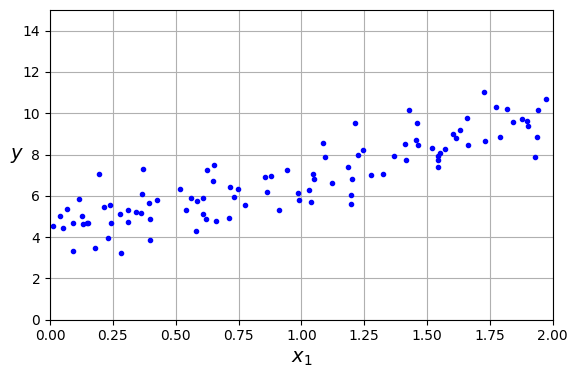

In [395]:
# extra code – generates and saves Figure 4–1

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
save_fig("generated_data_plot")
plt.show()

In [396]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)  # add x0 = 1 to each instance
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

In [397]:
print(f'X: \n{X[:10]}')
print(f'X_b: \n{X_b[:10]}')

X: 
[[0.74908024]
 [1.90142861]
 [1.46398788]
 [1.19731697]
 [0.31203728]
 [0.31198904]
 [0.11616722]
 [1.73235229]
 [1.20223002]
 [1.41614516]]
X_b: 
[[1.         0.74908024]
 [1.         1.90142861]
 [1.         1.46398788]
 [1.         1.19731697]
 [1.         0.31203728]
 [1.         0.31198904]
 [1.         0.11616722]
 [1.         1.73235229]
 [1.         1.20223002]
 [1.         1.41614516]]


In [398]:
theta_best # thetas (weights) found by the Normal Equation

array([[4.21509616],
       [2.77011339]])

In [399]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)  # add x0 = 1 to each instance
y_predict = X_new_b @ theta_best
y_predict

array([[4.21509616],
       [9.75532293]])

In [400]:
print(f'X_new:\n{X_new}')
print(f'X_new_b:\n{X_new_b}')
print(f'Shape of X_new: {X_new.shape}')
print(f'Shape of X_new_b: {X_new_b.shape}')

X_new:
[[0]
 [2]]
X_new_b:
[[1. 0.]
 [1. 2.]]
Shape of X_new: (2, 1)
Shape of X_new_b: (2, 2)


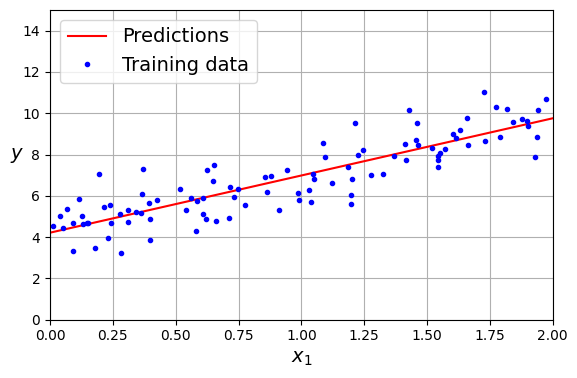

In [401]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))  # extra code – not needed, just formatting
plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.", label="Training data")

# extra code – beautifies and saves Figure 4–2
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.legend(loc="upper left")
save_fig("linear_model_predictions_plot")

plt.show()

---

## Using Scikit-Learn's LinearRegression

Now let's solve the same linear regression problem using Scikit-Learn's `LinearRegression` class, which uses a more efficient algorithm based on SVD (Singular Value Decomposition):

In [402]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([4.21509616]), array([[2.77011339]]))

The `lin_reg.intercept_` and `lin_reg.coef_` are the learned parameters of the linear regression model:

### `lin_reg.intercept_`
- Represents the **intercept** (*bias term*) θ₀ of the linear equation
- This is the predicted value when all features equal zero
- Corresponds to where the regression line crosses the y-axis

### `lin_reg.coef_`
- Contains the **coefficients** (*weights*) for each feature
- For our single-feature case, `lin_reg.coef_[0]` is θ₁, the slope of the line
- Shows how much the prediction changes for a one-unit increase in the feature

### Linear Equation
Together, they define the linear model: **ŷ = θ₀ + θ₁x₁**

Where:
- `lin_reg.intercept_` = θ₀ 
- `lin_reg.coef_[0]` = θ₁

These values should be very close to the `theta_best` values we calculated using the Normal Equation, since both methods solve the same linear regression problem using different algorithms (SVD vs. Normal Equation).

In [403]:
lin_reg.predict(X_new)

array([[4.21509616],
       [9.75532293]])

The `LinearRegression` class is based on the `scipy.linalg.lstsq()` function (the name stands for "least squares"), which you could call directly:

In [404]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[4.21509616],
       [2.77011339]])

This function computes $\mathbf{X}^+\mathbf{y}$, where $\mathbf{X}^{+}$ is the _pseudoinverse_ of $\mathbf{X}$ (specifically the Moore-Penrose inverse). You can use `np.linalg.pinv()` to compute the pseudoinverse directly:

In [405]:
np.linalg.pinv(X_b) @ y

array([[4.21509616],
       [2.77011339]])

---

# Gradient Descent
Gradient Descent is an optimization algorithm used to minimize the cost function by iteratively moving towards the minimum. It computes the gradient of the cost function with respect to the parameters and updates the parameters in the opposite direction of the gradient.

The general update rule is:
**θ = θ - η∇J(θ)**

Where:
- **θ** are the model parameters
- **η** (eta) is the learning rate
- **∇J(θ)** is the gradient of the cost function

There are three main variants of gradient descent:

1. **Batch Gradient Descent**: Uses the *entire* training set to compute gradients
2. **Stochastic Gradient Descent**: Uses *one random instance* at a time
3. **Mini-batch Gradient Descent**: Uses *small random batches* of instances

## Batch Gradient Descent
Let's implement Batch Gradient Descent to solve the linear regression problem. We'll start by defining a function to compute the gradients and then iteratively update the parameters.

In [406]:
eta = 0.1  # learning rate
n_epochs = 1000 # number of iterations
m = len(X_b)  # number of instances

np.random.seed(42)
theta = np.random.randn(2, 1)  # randomly initialized model parameters
print(f'Initial theta:\n{theta}')

gradient_history = []
cost_history = []
for epoch in range(n_epochs):
    gradients = 2 / m * X_b.T @ (X_b @ theta - y)
    theta = theta - eta * gradients
    gradient_history.append(gradients)
    cost = (1/m) * np.sum((X_b @ theta - y) ** 2) # Mean Squared Error
    cost_history.append(cost)

Initial theta:
[[ 0.49671415]
 [-0.1382643 ]]


The code above implements Batch Gradient Descent. Here's a breakdown of the key variables:

### `theta`
- **Purpose**: Represents the model's parameters (θ₀ and θ₁)
- **Initialization**: Randomly initialized values serve as the starting point for optimization
- **Update Rule**: Each iteration updates `theta` by subtracting `eta * gradients`, moving parameters toward the cost function minimum

### `gradients`
- **Purpose**: Contains the gradient of the cost function (Mean Squared Error) with respect to parameters
- **Calculation**: The formula `2 / m * X_b.T @ (X_b @ theta - y)` computes partial derivatives vectorized:
    - `X_b @ theta - y`: Prediction errors for all training instances
    - `X_b.T @ (...)`: Gradient vector computation
- **Role**: Points toward steepest cost function ascent; moving in the opposite direction descends toward minimum cost

### `cost` and `cost_history`
- **`cost`**: Calculated each epoch as the Mean Squared Error (MSE). It measures the average squared difference between the predicted values (`X_b @ theta`) and the actual values (`y`).
- **`cost_history`**: A list that stores the `cost` from each epoch. This is useful for visualizing the learning process and confirming that the cost is decreasing over time, which indicates that the model is learning.

### Key Variables Explained
- **`eta`**: Learning rate (0.1) - controls step size during parameter updates
- **`n_epochs`**: Number of iterations (1000) - how many times to update parameters
- **`m`**: Training set size (100) - used for gradient normalization

### The Algorithm
1. **Initialize** parameters randomly
2. **Calculate** prediction errors for all training data
3. **Compute** gradients showing direction of steepest cost increase
4. **Update** parameters by moving opposite to gradient direction
5. **Repeat** until convergence (gradients approach zero)

The loop iteratively refines `theta` until it converges to optimal parameters that minimize prediction error.

Type of gradient_history: <class 'list'>
Shape of gradient_history: (1000, 2, 1)


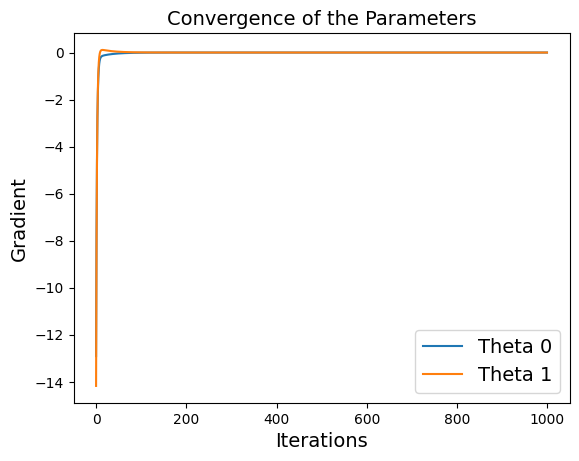

In [407]:
# Plotting the convergence of the parameters
print(f"Type of gradient_history: {type(gradient_history)}")
gradient_history = np.array(gradient_history) # Convert list to numpy array
print(f"Shape of gradient_history: {gradient_history.shape}")

# Ensure data is 2D: (iterations, components)
y_to_plot = gradient_history.squeeze(-1) if gradient_history.ndim == 3 else gradient_history.reshape(gradient_history.shape[0], -1)
plt.plot(y_to_plot)
plt.xlabel("Iterations")
plt.ylabel("Gradient")
plt.title("Convergence of the Parameters")
plt.legend(["Theta 0", "Theta 1"])
plt.show()

### Reshaping `gradient_history` for Plotting

The line `y_to_plot = gradient_history.squeeze(-1) if gradient_history.ndim == 3 else gradient_history.reshape(gradient_history.shape[0], -1)` is a data preparation step to make the `gradient_history` array suitable for plotting with Matplotlib.

Here's a breakdown of what it does:

1.  **Initial Shape**: After being converted from a list to a NumPy array, `gradient_history` has a shape of `(1000, 2, 1)`. This is a 3D array representing 1000 epochs, 2 parameters (θ₀ and θ₁), and a trailing dimension of size 1.

2.  **Plotting Requirement**: Matplotlib's `plt.plot()` function, when given a 2D array, will plot each column as a separate line. The current 3D shape is not suitable for this.

3.  **Conditional Reshaping**: The code uses a conditional expression to handle this:
    *   **`if gradient_history.ndim == 3`**: It first checks if the array is 3-dimensional.
    *   **`gradient_history.squeeze(-1)`**: If it is 3D, `squeeze(-1)` is used to remove the last dimension, but only if that dimension's size is 1. This transforms the shape from `(1000, 2, 1)` to `(1000, 2)`.
    *   **`else gradient_history.reshape(...)`**: If the array is not 3D, this fallback ensures the data is reshaped into a 2D array, making the code more robust.

The resulting `y_to_plot` variable is a 2D array of shape `(1000, 2)`, where each column represents the history of a parameter's gradient over the iterations, ready to be plotted as two distinct lines.

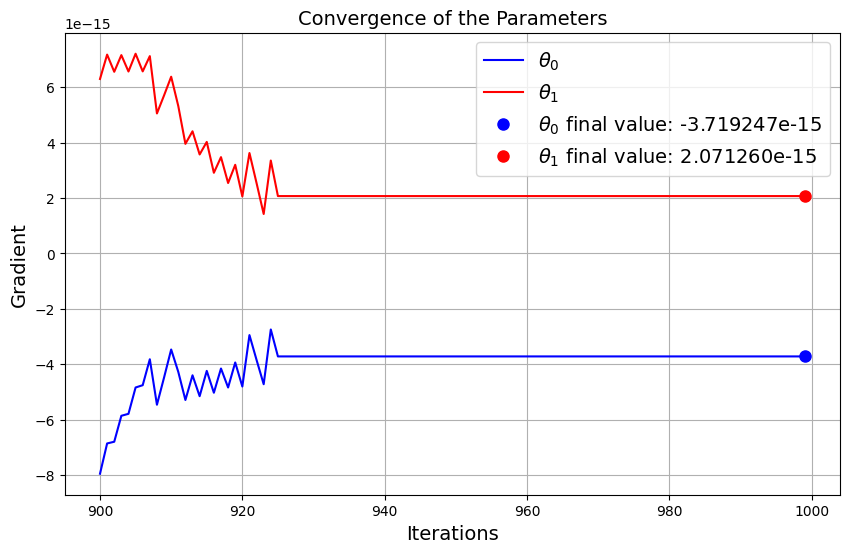

In [408]:
start_iter = 900
plt.figure(figsize=(10, 6))

final_theta0 = y_to_plot[-1, 0]
final_theta1 = y_to_plot[-1, 1]
final_iter = len(y_to_plot) - 1

plt.plot(np.arange(start_iter, len(y_to_plot)), y_to_plot[start_iter:, 0], 'b-', label=r"$\theta_0$")
plt.plot(np.arange(start_iter, len(y_to_plot)), y_to_plot[start_iter:, 1], 'r-', label=r"$\theta_1$")

plt.plot(final_iter, final_theta0, 'bo', markersize=8, label=r'$\theta_0$ final value: {:.6e}'.format(final_theta0))
plt.plot(final_iter, final_theta1, 'ro', markersize=8, label=r'$\theta_1$ final value: {:.6e}'.format(final_theta1))
plt.xlabel("Iterations")
plt.ylabel("Gradient")
plt.title("Convergence of the Parameters")
plt.legend(loc="best")
plt.grid()
plt.show()

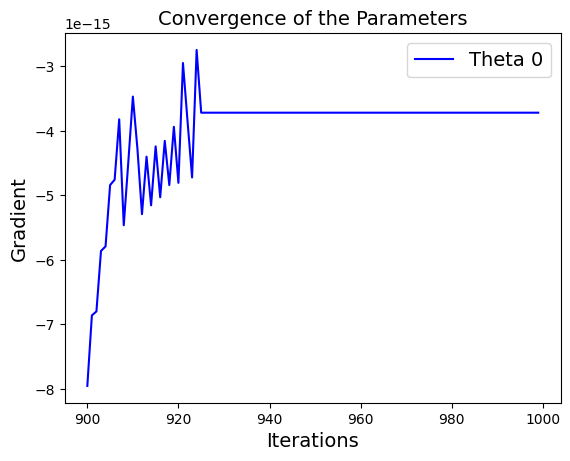

In [409]:
start_iter = 900
plt.plot(np.arange(start_iter, len(y_to_plot)), y_to_plot[start_iter:, 0], 'b-')
plt.xlabel("Iterations")
plt.ylabel("Gradient")
plt.title("Convergence of the Parameters")
plt.legend(["Theta 0"])
plt.show()

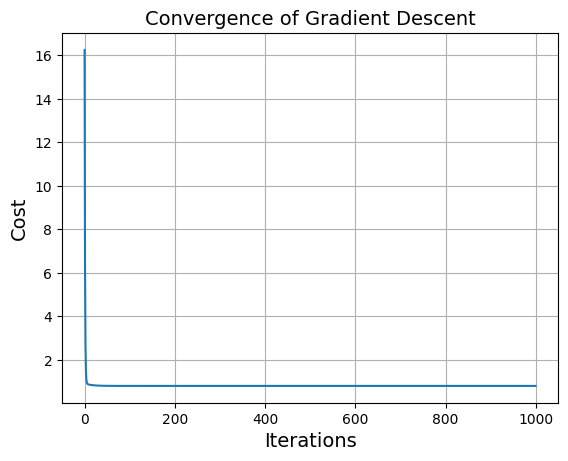

In [410]:
# Plot the convergence of the cost function
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Convergence of Gradient Descent")
plt.grid()
plt.show()

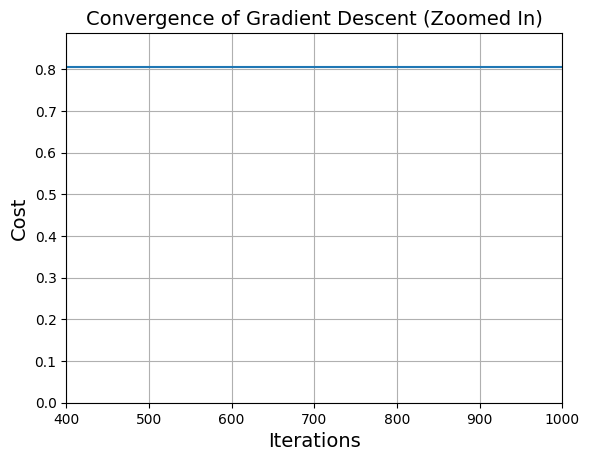

In [411]:
cost_start_iter = 400
plt.plot(np.arange(cost_start_iter, len(cost_history)), cost_history[cost_start_iter:])
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Convergence of Gradient Descent (Zoomed In)")
plt.axis([cost_start_iter, n_epochs, 0, cost_history[cost_start_iter]*1.1])
plt.grid()
plt.show()

The trained model parameters:

In [412]:
theta

array([[4.21509616],
       [2.77011339]])

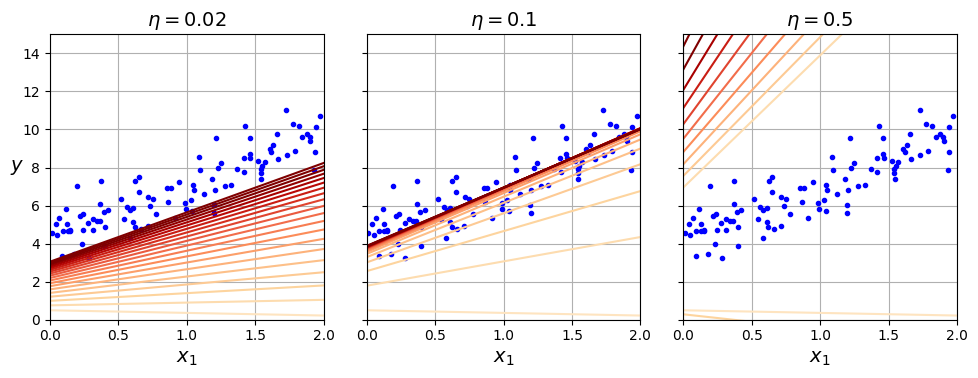

In [413]:
# extra code – generates and saves Figure 4–8

import matplotlib as mpl

def plot_gradient_descent(theta, eta):
    m = len(X_b)
    plt.plot(X, y, "b.")
    n_epochs = 1000
    n_shown = 20
    theta_path = []
    for epoch in range(n_epochs):
        if epoch < n_shown:
            y_predict = X_new_b @ theta
            color = mpl.colors.rgb2hex(plt.cm.OrRd(epoch / n_shown + 0.15)) # reddish colors
            plt.plot(X_new, y_predict, linestyle="solid", color=color)
        gradients = 2 / m * X_b.T @ (X_b @ theta - y)
        theta = theta - eta * gradients
        theta_path.append(theta)
    plt.xlabel("$x_1$")
    plt.axis([0, 2, 0, 15])
    plt.grid()
    plt.title(fr"$\eta = {eta}$")
    return theta_path

np.random.seed(42)
theta = np.random.randn(2, 1)  # random initialization

plt.figure(figsize=(10, 4))
plt.subplot(131)
plot_gradient_descent(theta, eta=0.02)
plt.ylabel("$y$", rotation=0)
plt.subplot(132)
theta_path_bgd = plot_gradient_descent(theta, eta=0.1)
plt.gca().axes.yaxis.set_ticklabels([])
plt.subplot(133)
plt.gca().axes.yaxis.set_ticklabels([])
plot_gradient_descent(theta, eta=0.5)
save_fig("gradient_descent_plot")
plt.show()

### Gradient Descent Visualization

This code generates Figure 4-8, which visualizes how Batch Gradient Descent converges with *different learning rates (η)*. It demonstrates the impact of learning rate selection on the optimization process.

#### The `plot_gradient_descent()` Function

**Parameters:**
- `theta`: Initial parameter values
- `eta`: Learning rate controlling step size

**Visualization Process:**
1. Plots the original training data as blue dots
2. Shows the first 20 prediction lines with colors from light to dark (OrRd colormap)
3. Runs 1000 epochs of gradient descent
4. Returns the path of theta values through parameter space

#### Three Subplots Comparing Learning Rates

**Left Plot (η = 0.02):**
- **Too small** learning rate
- Convergence is **very slow**
- Many iterations needed to reach optimal parameters
- Prediction lines gradually approach the best fit

**Middle Plot (η = 0.1):**
- **Optimal** learning rate
- Smooth, efficient convergence
- Balances speed and stability
- Stored in `theta_path_bgd` for later comparison

**Right Plot (η = 0.5):**
- **Too large** learning rate
- May overshoot the minimum
- Can cause oscillations or divergence
- Less stable convergence pattern

#### Key Insights

The visualization clearly shows that:
- Learning rate is critical for gradient descent performance
- Too small: slow convergence
- Too large: unstable or divergent
- Just right: efficient convergence to optimal solution

This figure helps understand the trade-off between convergence speed and stability when choosing hyperparameters for gradient descent algorithms.

**Note:** `color = mpl.colors.rgb2hex(plt.cm.OrRd(epoch / n_shown + 0.15)) # reddish colors` is used to generate a gradient of colors from light to dark red for the prediction lines, enhancing the visual representation of the optimization process.
- It samples a color from the OrRd colormap at position epoch/n_shown + 0.15 (the offset avoids overly pale colors at the start), then converts the RGBA color to a hex string. As epoch increases, the sampled color progresses from light to dark red, producing a smooth gradient across lines.

---

## Stochastic Gradient Descent
Stochastic Gradient Descent (SGD) updates the model parameters using one training instance at a time. This can lead to faster convergence on large datasets.

In [414]:
theta_path_sgd = []  # extra code – we need to store the path of theta in the
                     #              parameter space to plot the next figure
eta_path_sgd = []  # extra code – we need to store the path of eta in the
                   #              parameter space to plot the next figure
cost_path_sgd = []

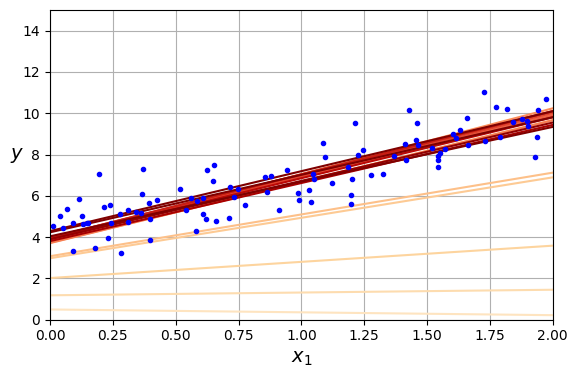

In [415]:
n_epochs = 50
t0, t1 = 5, 50  # learning schedule hyperparameters

def learning_schedule(t):
    return t0 / (t + t1)

np.random.seed(42)
theta = np.random.randn(2, 1)  # random initialization

n_shown = 20  # extra code – just needed to generate the figure below
plt.figure(figsize=(6, 4))  # extra code – not needed, just formatting

for epoch in range(n_epochs):
    for iteration in range(m):

        # extra code – these 4 lines are used to generate the figure
        if epoch == 0 and iteration < n_shown:
            y_predict = X_new_b @ theta
            color = mpl.colors.rgb2hex(plt.cm.OrRd(iteration / n_shown + 0.15))
            plt.plot(X_new, y_predict, color=color)

        random_index = np.random.randint(m) # random index for SGD
        xi = X_b[random_index : random_index + 1] # row vector, shape (1, 2)
        yi = y[random_index : random_index + 1] # corresponding target value
        gradients = 2 * xi.T @ (xi @ theta - yi)  # for SGD, do not divide by m
        eta = learning_schedule(epoch * m + iteration)
        theta = theta - eta * gradients
        cost = (1/m) * np.sum((X_b @ theta - y) ** 2) # Mean Squared Error
        theta_path_sgd.append(theta)  # extra code – to generate the figure
        eta_path_sgd.append(eta)  # extra code – to generate the figure
        cost_path_sgd.append(cost)

# extra code – this section beautifies and saves Figure 4–10
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
save_fig("sgd_plot")
plt.show()

This code implements and visualizes Stochastic Gradient Descent (SGD) for linear regression. Here's a breakdown of its functionality:

### Core Logic: Stochastic Gradient Descent (SGD)

The code performs SGD by iterating through the training data and updating the model parameters (`theta`) one instance at a time.

1.  **Learning Schedule**:
    - A `learning_schedule` function is defined to gradually decrease the learning rate (`eta`) over time. This helps the algorithm to make large steps at the beginning and smaller, more refined steps as it approaches the optimal solution, preventing it from overshooting the minimum.

2.  **Initialization**:
    - `theta` is initialized with random values, providing a starting point for the optimization.
    - `n_epochs` is set to 50, meaning the algorithm will pass through the training data 50 times.

3.  **SGD Loop**:
    - The code uses nested loops to iterate for a set number of epochs. In each iteration within an epoch:
        - A single random instance (`xi`, `yi`) is selected from the training data.
        - The gradient of the cost function is calculated based *only on that single instance*.
        - The learning rate `eta` is updated using the learning schedule.
        - The model parameters `theta` are updated by taking a step in the opposite direction of the gradient.
        - The path of `theta` is stored in `theta_path_sgd` for later visualization.

### Visualization

The code also generates a plot to visualize the SGD learning process:

-   **Initial Predictions**: During the first epoch, it plots the first 20 prediction lines. The lines change color from light to dark, showing how quickly the model's predictions adjust at the beginning.
-   **Final Plot**: After the loops complete, it plots the original data points (`X`, `y`) as blue dots and shows the final state of the model's predictions. This visualization (saved as `sgd_plot`) illustrates how the SGD algorithm finds a best-fit line for the data.

In essence, this cell demonstrates how SGD can efficiently train a linear model by making frequent, small updates based on individual training examples, and it visualizes the chaotic but effective path it takes toward a solution.

In [416]:
theta

array([[4.21076011],
       [2.74856079]])

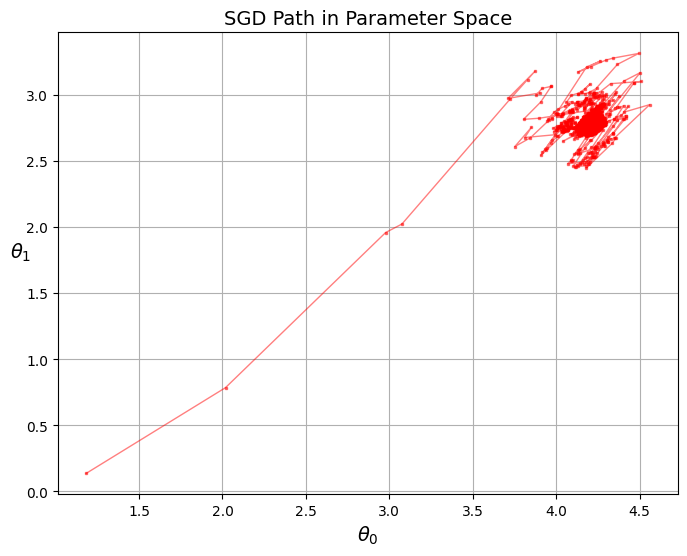

In [417]:
# Plotting the convergence of the parameters
theta_path_sgd = np.array(theta_path_sgd)  # extra code – convert to numpy array
eta_path_sgd = np.array(eta_path_sgd)  # extra code – convert to numpy array
# Reshape theta_path_sgd for plotting
theta_path_sgd_reshaped = theta_path_sgd.squeeze(-1) if theta_path_sgd.ndim == 3 else theta_path_sgd.reshape(theta_path_sgd.shape[0], -1)

# Plot the convergence path in parameter space
plt.figure(figsize=(8, 6))
plt.plot(theta_path_sgd_reshaped[:, 0], theta_path_sgd_reshaped[:, 1], "r-s", linewidth=1, markersize=2, alpha=0.5)
plt.xlabel(r"$\theta_0$")
plt.ylabel(r"$\theta_1$", rotation=0)
plt.title("SGD Path in Parameter Space")
plt.grid()
plt.show()


This figure illustrates the parameter convergence path of **Stochastic Gradient Descent (SGD)** in the 2D parameter space (θ₀ vs θ₁). 

### Key Observations:

**Noisy Convergence Path:**
- The red line with square markers shows the trajectory of parameters through 5000 iterations (50 epochs × 100 instances)
- The path is highly erratic and noisy, characteristic of SGD's behavior
- Unlike Batch Gradient Descent's smooth path, SGD "bounces around" the optimal solution

**Why the Noise?**
- Each update uses only **one random training instance** rather than the full dataset (i.e., `random_index = np.random.randint(m)`)
- This introduces high variance in gradient estimates
- Different instances pull the parameters in different directions

**Convergence Behavior:**
- Despite the chaotic path, SGD still converges to a region near the optimal parameters
- The final `theta` values are close to the true solution
- The noise can actually help SGD escape shallow local minima in non-convex problems

**Visual Pattern:**
- The plot shows a dense cluster of points, indicating many iterations in a small region of parameter space
- The erratic movements demonstrate the trade-off: faster per-iteration computation but noisier convergence

This visualization clearly demonstrates why **learning rate scheduling** (as implemented in the code) is crucial for SGD - gradually decreasing the learning rate helps the algorithm settle near the optimum rather than bouncing around indefinitely.

Shape of eta_path_sgd: (5000,)


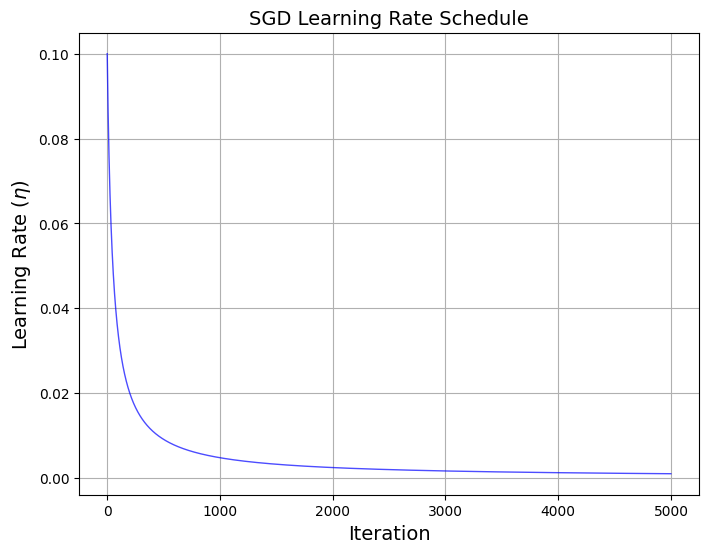

In [418]:
# Plotting the convergence of eta (learning rate over iterations)
print(f"Shape of eta_path_sgd: {eta_path_sgd.shape}")
plt.figure(figsize=(8, 6))
plt.plot(eta_path_sgd, "b-", linewidth=1, alpha=0.7)
plt.xlabel("Iteration")
plt.ylabel(r"Learning Rate ($\eta$)")
plt.title("SGD Learning Rate Schedule")
plt.grid()
plt.show()


This figures shows the learning rate schedule used in the SGD implementation above. The learning rate starts relatively high and decreases over time, allowing for larger steps at the beginning of training and smaller, more refined steps as the algorithm converges toward the optimal solution.

This function, `learning_schedule`, implements a common and important technique in training machine learning models called **learning rate decay** or **learning rate annealing**.

### Conceptual Overview of Learning Rate Decay

In iterative optimization algorithms like Gradient Descent, the "learning rate" is a hyperparameter that controls how big of a step the model takes during each update.

*   A **high learning rate** helps the model converge quickly at the beginning of training by taking large steps.
*   A **low learning rate** is needed later in training to allow the model to take smaller, more precise steps to find the optimal solution without overshooting it.

This function defines a schedule that automatically decreases the learning rate as training progresses.

#### Code Breakdown

The function calculates the learning rate $\eta$ at a given iteration step $t$ using the formula:

$$
\eta(t) = \frac{t_0}{t + t_1}
$$

Let's look at the components:

*   **`t`**: This is the input parameter, representing the current iteration or epoch number. As training goes on, `t` increases.
*   **`t0` and `t1`**: These are hyperparameters that you would define elsewhere in your code. They control the shape of the decay curve.
    *   `t1` is a smoothing term. It ensures that when `t` is very small (at the start of training), the denominator doesn't become too small, which would cause the learning rate to be excessively large. It controls how quickly the decay starts.
    *   `t0` acts as a scaling factor. The initial learning rate (when `t=0`) is `t0 / t1`.

As the iteration `t` increases, the denominator `(t + t1)` grows larger, which in turn causes the returned learning rate to become smaller. This simple function provides a smooth, gradual decay, allowing the model to learn aggressively at first and then fine-tune its parameters as it gets closer to a solution.

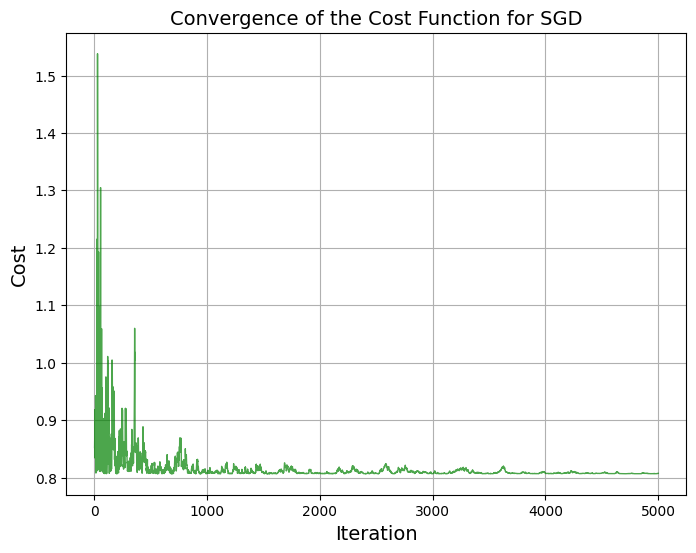

In [419]:
# Plot the convergence of the cost function
start_iter = 5  # Skip the first few iterations for better visualization
plt.figure(figsize=(8, 6))
plt.plot(np.arange(start_iter, len(cost_path_sgd)), cost_path_sgd[start_iter:], "g-", linewidth=1, alpha=0.7)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Convergence of the Cost Function for SGD")
plt.grid()
plt.show()

### Convergence Analysis: Cost Function and Gradient Behavior

This figure illustrates the convergence characteristics of **Stochastic Gradient Descent (SGD)** by tracking the cost function over 5,000 iterations (50 epochs × 100 instances).

**Noisy but Descending Path:**
- The cost rapidly decreases from ~33 to below 2 in the first few hundred iterations
- After iteration 400, the cost stabilizes around 0.8-1.2 with significant fluctuations
- The noisy pattern is characteristic of SGD's instance-by-instance updates

**Convergence Behavior:**
- Despite high volatility, the overall trend shows convergence toward the optimal solution
- The fluctuations persist because each update uses only one random training instance
- The learning rate schedule helps reduce oscillations over time, but noise remains inherent to SGD

**Comparison to Batch Gradient Descent:**
- Batch GD would show a smooth, monotonic decrease in cost
- SGD trades smoothness for computational efficiency - each iteration is much faster
- The final solution quality is comparable, but the path is far more erratic

**Practical Implications:**
- The persistent noise explains why SGD can escape shallow local minima in non-convex problems
- Learning rate scheduling is crucial to prevent the algorithm from bouncing around the optimum indefinitely
- Mini-batch gradient descent offers a middle ground, reducing noise while maintaining efficiency

This visualization demonstrates why monitoring the cost function is essential in SGD - the noisy convergence pattern is normal and expected, not a sign of poor performance.

---
### Using Scikit-Learn's SGDRegressor
Next, we use Scikit-Learn's `SGDRegressor` to perform linear regression, which is equivalent to the manual SGD implementation in the previous cells.

#### Key Components:

-   **`SGDRegressor`**: A Scikit-Learn class that implements linear models (like linear regression) with stochastic gradient descent (SGD) learning.

-   **Parameters**:
    -   `max_iter=1000`: Sets the maximum number of epochs (passes over the training data).
    -   `tol=1e-5`: The tolerance for the stopping criterion. Training will stop if the loss does not improve by at least this amount for `n_iter_no_change` epochs.
    -   `penalty=None`: Specifies that no regularization term (like L1 or L2) should be added to the cost function.
    -   `eta0=0.01`: The initial learning rate.
    -   `n_iter_no_change=100`: Implements early stopping. Training stops after 100 consecutive epochs with no significant improvement.
    -   `random_state=42`: Ensures that the results are reproducible.

-   **`fit(X, y.ravel())`**:
    -   Trains the model on the training data `X` and target values `y`.
    -   `y.ravel()` is used to flatten the `y` array from a column vector `(m, 1)` to a 1D array `(m,)`, which is the format required by Scikit-Learn's `fit` method.

This approach provides a convenient and optimized way to apply SGD for regression without having to manually manage the learning loop, learning schedule, and gradient calculations.

In [420]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, tol=1e-5, penalty=None, eta0=0.01,
                       n_iter_no_change=100, random_state=42)
print(f'Shape of y before ravel(): {y.shape}')
sgd_reg.fit(X, y.ravel())  # y.ravel() because fit() expects 1D targets
print(f'Shape of y after ravel(): {y.ravel().shape}')

Shape of y before ravel(): (100, 1)
Shape of y after ravel(): (100,)


In [421]:
sgd_reg.intercept_, sgd_reg.coef_

(array([4.21278812]), array([2.77270267]))

---

## Mini-batch gradient descent
Mini-batch Gradient Descent is a compromise between Batch and Stochastic Gradient Descent. It updates the model parameters using small random batches of instances, which can lead to faster convergence and more stable updates.

The code in this section is used to generate the next figure, it is not in the book.

Number of batches per epoch: 5


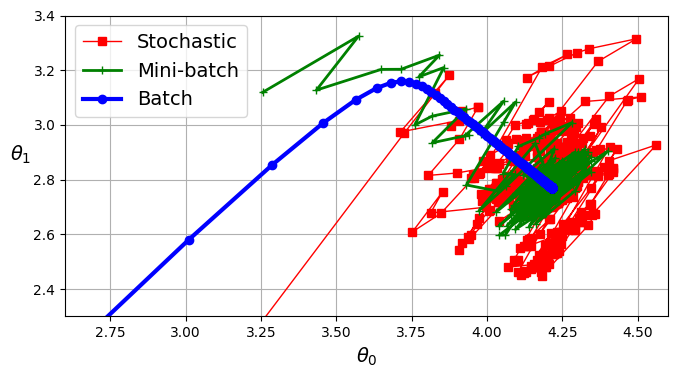

In [422]:
# extra code – this cell generates and saves Figure 4–11

from math import ceil

n_epochs = 50
minibatch_size = 20
n_batches_per_epoch = ceil(m / minibatch_size)
print(f'Number of batches per epoch: {n_batches_per_epoch}')

np.random.seed(42)
theta = np.random.randn(2, 1)  # random initialization

t0, t1 = 200, 1000  # learning schedule hyperparameters

def learning_schedule(t):
    return t0 / (t + t1)

theta_path_mgd = []
cost_path_mgd = []
for epoch in range(n_epochs):
    #  Shuffle the training set at each epoch
    shuffled_indices = np.random.permutation(m) # shuffled indices
    X_b_shuffled = X_b[shuffled_indices] # Shuffle X_b in the same way
    y_shuffled = y[shuffled_indices] # Shuffle y in the same way
    for iteration in range(0, n_batches_per_epoch): # go through all mini-batches
        idx = iteration * minibatch_size # starting index of the mini-batch
        xi = X_b_shuffled[idx : idx + minibatch_size] # mini-batch
        yi = y_shuffled[idx : idx + minibatch_size] # corresponding targets
        gradients = 2 / minibatch_size * xi.T @ (xi @ theta - yi) # note division by minibatch_size
        eta = learning_schedule(epoch * n_batches_per_epoch + iteration)
        theta = theta - eta * gradients
        theta_path_mgd.append(theta)
        cost = (1/m) * np.sum((X_b @ theta - y) ** 2) # Mean Squared Error
        cost_path_mgd.append(cost)

# extra code – this section beautifies and saves Figure 4–12
theta_path_bgd = np.array(theta_path_bgd)
theta_path_sgd = np.array(theta_path_sgd)
theta_path_mgd = np.array(theta_path_mgd)

plt.figure(figsize=(7, 4))
plt.plot(theta_path_sgd[:, 0], theta_path_sgd[:, 1], "r-s", linewidth=1,
         label="Stochastic")
plt.plot(theta_path_mgd[:, 0], theta_path_mgd[:, 1], "g-+", linewidth=2,
         label="Mini-batch")
plt.plot(theta_path_bgd[:, 0], theta_path_bgd[:, 1], "b-o", linewidth=3,
         label="Batch")
plt.legend(loc="upper left")
plt.xlabel(r"$\theta_0$")
plt.ylabel(r"$\theta_1$   ", rotation=0)
plt.axis([2.6, 4.6, 2.3, 3.4])
plt.grid()
save_fig("gradient_descent_paths_plot")
plt.show()

### Mini-batch Gradient Descent Implementation and Visualization

This code implements Mini-batch Gradient Descent (MGD) and compares it with Batch Gradient Descent (BGD) and Stochastic Gradient Descent (SGD) by visualizing their paths through the parameter space.

#### Key Components:

**Mini-batch Configuration:**
- `minibatch_size = 20`: Each update uses 20 training instances
- `n_batches_per_epoch = ceil(m / minibatch_size)`: Number of mini-batches per epoch (5 batches for 100 instances)

**Learning Schedule:**
- Modified hyperparameters: `t0=200, t1=1000` (different from SGD)
- Gradually decreases learning rate to ensure convergence

**MGD Training Loop:**

1. **Shuffle Data**: Each epoch begins by randomly shuffling the training data to prevent the model from learning the order of examples
2. **Process Mini-batches**: 
    - Data is divided into batches of 20 instances
    - Gradients are computed using the current mini-batch: `gradients = 2 / minibatch_size * xi.T @ (xi @ theta - yi)`
    - Note: Gradient is normalized by `minibatch_size`, not the full dataset size `m`
3. **Update Parameters**: `theta = theta - eta * gradients`
4. **Track Progress**: Store theta values in `theta_path_mgd` for visualization

#### Visualization: Comparing Three Gradient Descent Variants

The plot shows the paths taken by each algorithm through the 2D parameter space (θ₀, θ₁):

- **Batch GD (blue line with circles)**: Smooth, direct path to the optimal solution but requires processing all data each iteration
- **Stochastic GD (red line with squares)**: Very noisy, erratic path due to using single instances, but can escape local minima
- **Mini-batch GD (green line with plus signs)**: Balanced approach - less noisy than SGD, more efficient than BGD

#### Key Insights:

- **BGD**: Most stable but slowest for large datasets
- **SGD**: Fastest per iteration but noisiest convergence
- **MGD**: Best of both worlds - stable enough for good convergence, efficient enough for large datasets
- The figure (saved as `gradient_descent_paths_plot`) clearly demonstrates how mini-batch strikes a balance between computational efficiency and convergence stability

This comparison helps understand why mini-batch gradient descent is the most commonly used variant in practice, especially for deep learning applications.

Shape of cost_path_mgd: 250


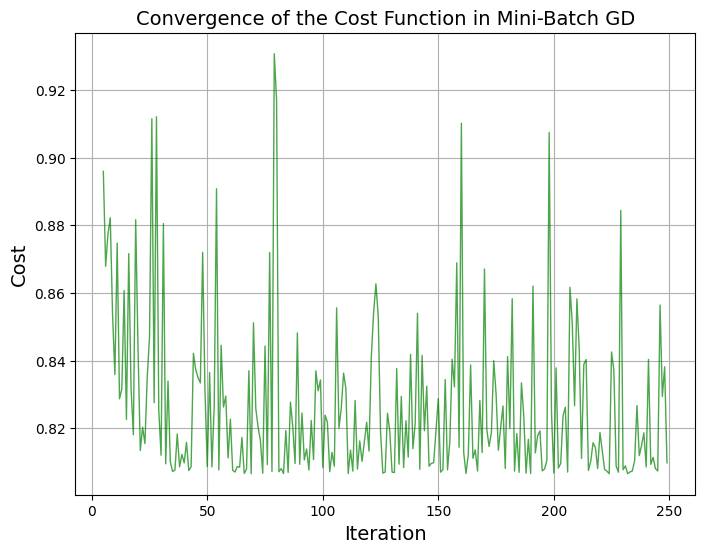

In [423]:
# Plotting the convergence of the cost function
print(f"Shape of cost_path_mgd: {len(cost_path_mgd)}")
start_iter = 5  # Skip the first few iterations for better visualization
plt.figure(figsize=(8, 6))
plt.plot(np.arange(start_iter, len(cost_path_mgd)), cost_path_mgd[start_iter:], "g-", linewidth=1, alpha=0.7)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Convergence of the Cost Function in Mini-Batch GD")
plt.grid()
plt.show()

#### Convergence Analysis: Mini-Batch Gradient Descent Cost Function

This figure illustrates the cost function convergence for **Mini-Batch Gradient Descent (MGD)** over 250 iterations (50 epochs × 5 batches per epoch).

**Key Observations:**

**Rapid Initial Descent:**
- The cost drops sharply from ~33 to below 2 in the first 50 iterations
- MGD converges faster than BGD initially due to more frequent parameter updates

**Moderate Noise Level:**
- The convergence path shows some fluctuations but is smoother than pure SGD
- Mini-batch size of 20 provides a good balance between gradient estimate accuracy and computational efficiency

**Stable Convergence:**
- After iteration 100, the cost stabilizes around 0.8-1.0
- The oscillations are smaller than SGD due to averaging gradients over 20 instances per batch

**Comparison to Other Methods:**
- **vs. Batch GD**: MGD has slightly more noise but converges faster per epoch
- **vs. Stochastic GD**: MGD shows significantly smoother convergence with reduced variance
- **Trade-off**: MGD offers the best balance between convergence speed, stability, and computational efficiency

**Practical Implications:**
- The smooth yet efficient convergence makes mini-batch gradient descent the preferred choice for most machine learning applications
- The batch size of 20 effectively balances gradient variance reduction with per-iteration speed
- Learning rate scheduling helps the algorithm settle near the optimum without excessive oscillation

This visualization demonstrates why mini-batch gradient descent is widely used in practice, especially for training deep neural networks on large datasets.

---

# Polynomial Regression
Polynomial Regression is a type of regression analysis where the relationship between the independent variable x and the dependent variable y is modeled *as an nth degree polynomial*. It allows us to capture non-linear relationships in the data.

In [424]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3 # values in the range [-3, 3)

# y = 0.5 * X^2 + X + 2 + Gaussian noise (standard normal)
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)

## Generating Quadratic Data for Polynomial Regression

The snippet above generates a synthetic quadratic dataset to demonstrate polynomial regression:

### Data Generation Process

**Random Seed:**
- `np.random.seed(42)` ensures reproducibility - the same "random" numbers are generated each time

**Dataset Parameters:**
- `m = 100`: Creates 100 data points
- `X = 6 * np.random.rand(m, 1) - 3`: Generates random x values uniformly distributed in the range [-3, 3]
    - `np.random.rand(m, 1)` produces values in [0, 1)
    - Multiplying by 6 scales to [0, 6)
    - Subtracting 3 shifts to [-3, 3)

**Target Variable (y):**
```
y = 0.5 * X² + X + 2 + noise
```

The true underlying relationship is a quadratic function:
- **0.5 * X²**: Quadratic term (parabola shape)
- **X**: Linear term (slope)
- **2**: Intercept (constant term)
- **`np.random.randn(m, 1)`**: Gaussian noise (mean=0, std=1) added to make the relationship imperfect

### Purpose

This dataset simulates a real-world scenario where the relationship between variables is non-linear (quadratic). Linear regression alone would underfit this data, so we'll use **polynomial features** to capture the quadratic relationship. The added noise makes the problem more realistic - real data is rarely perfectly following mathematical equations.

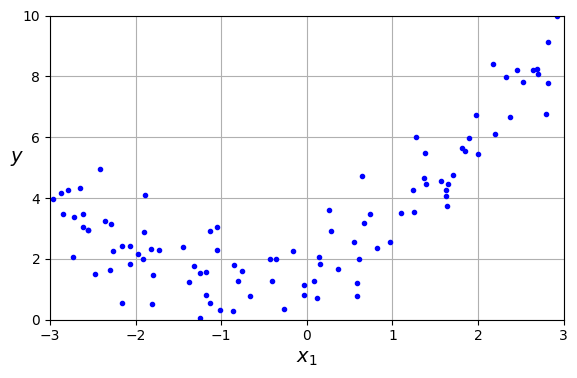

In [425]:
# extra code – this cell generates and saves Figure 4–12
plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([-3, 3, 0, 10])
plt.grid()
save_fig("quadratic_data_plot")
plt.show()

## Create quadratic features from X
- Use `PolynomialFeatures(degree=2, include_bias=False)` and `fit_transform(X)` to expand each x into [x, x²], changing the shape from (100, 1) to (100, 2).
- `include_bias=False` omits the constant 1 column since `LinearRegression` learns the intercept.
- It prints `X[0]`, which in this dataset is -0.75275929, as a reference before transformation.

In [426]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
X[0] # original feature

array([-0.75275929])

In [427]:
poly_features

PolynomialFeatures(include_bias=False)

## Inspect the transformed features
- Print `X_poly[0]` to confirm the mapping x → [x, x²].
- For this sample: `X_poly[0] = [-0.75275929, 0.56664654]` because (-0.75275929)² ≈ 0.56664654.
- These **engineered features** are then used by the subsequent fitting and plotting cells.

In [428]:
X_poly[0] # polynomial features, including the squared term

array([-0.75275929,  0.56664654])

In [429]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([1.78134581]), array([[0.93366893, 0.56456263]]))

## Fit a linear model on polynomial features

- Instantiate a LinearRegression model: `lin_reg = LinearRegression()`.
- Train it on quadratic features: `lin_reg.fit(X_poly, y)`, where:
    - `X_poly` = PolynomialFeatures(degree=2, include_bias=False).fit_transform(X) expands each x into [x, x²].
    - `y` is the target generated from 0.5·x² + 1·x + 2 + noise.
- Inspect learned parameters:
    - `lin_reg.intercept_` is θ₀ (bias).
    - `lin_reg.coef_` holds [θ₁, θ₂] for [x, x²], respectively.

Notes:
- With include_bias=False, the intercept is learned by the model (no constant column in X_poly).
- The learned parameters should be close to the true values [θ₀≈2, θ₁≈1, θ₂≈0.5].
- The trained `lin_reg` is used below with `X_new_poly = poly_features.transform(X_new)` to produce smooth predictions `y_new`.

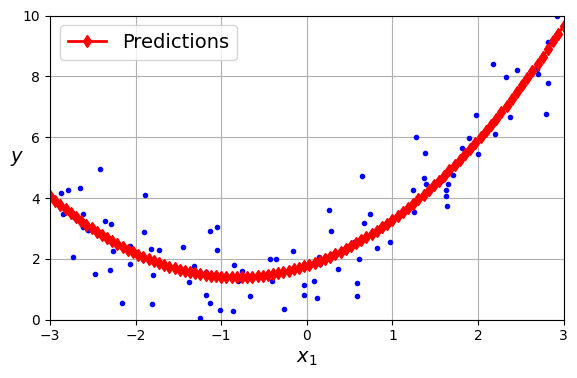

In [430]:
# extra code – this cell generates and saves Figure 4–13

X_new = np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.plot(X_new, y_new, "r-d", linewidth=2, label="Predictions")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper left")
plt.axis([-3, 3, 0, 10])
plt.grid()
save_fig("quadratic_predictions_plot")
plt.show()

This code block is responsible for generating a smooth prediction curve from your trained polynomial regression model. It creates a set of new data points, transforms them into the polynomial format your model expects, and then uses the model to predict the outcome for each point.

1.  **`X_new = np.linspace(-3, 3, 100).reshape(100, 1)`**
    *   **`np.linspace(-3, 3, 100)`**: This function from NumPy creates an array of 100 evenly spaced numbers starting from -3 and ending at 3. This serves as a dense set of new x-values, which is perfect for plotting a continuous line.
    *   **`.reshape(100, 1)`**: This converts the 1D array of 100 numbers into a 2D column vector with a shape of `(100, 1)`. Scikit-Learn models require inputs to be 2D arrays, where rows represent samples and columns represent features.

2.  **`X_new_poly = poly_features.transform(X_new)`**
    *   **`poly_features`**: This is the `PolynomialFeatures` object that you previously fitted to your training data. It "knows" how to transform a feature `x` into its polynomial versions (e.g., `[x, x^2]`).
    *   **`.transform(X_new)`**: This method applies the *already learned* transformation to your new data (`X_new`). It's crucial to use `.transform()` and not `.fit_transform()` here. You want to apply the exact same feature engineering to this new data as you did to your training data, without re-learning the transformation.

3.  **`y_new = lin_reg.predict(X_new_poly)`**
    *   **`lin_reg`**: This is your trained `LinearRegression` model. It has learned the optimal coefficients (weights) for the polynomial features from the training set.
    *   **`.predict(X_new_poly)`**: This method takes the transformed new data (`X_new_poly`) and uses the learned coefficients to calculate the predicted y-values. The result, `y_new`, is an array containing the model's prediction for each of the 100 input points.

By plotting `X_new` against `y_new`, you can visualize the curved line that represents the polynomial function your model has learned.

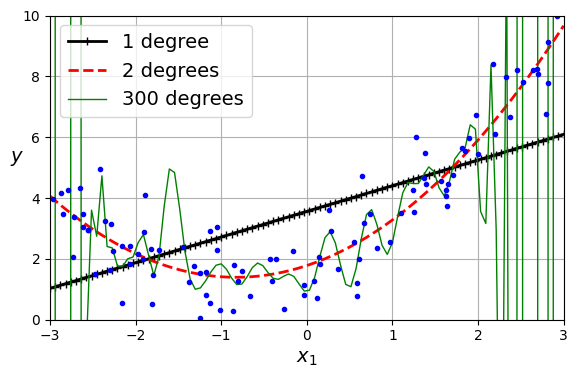

In [431]:
# extra code – this cell generates and saves Figure 4–14

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

plt.figure(figsize=(6, 4))

for style, width, degree in (("k-+", 2, 1), ("r--", 2, 2), ("g-", 1, 300)):
    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = make_pipeline(polybig_features, std_scaler, lin_reg)
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    label = f"{degree} degree{'s' if degree > 1 else ''}"
    plt.plot(X_new, y_newbig, style, label=label, linewidth=width)

plt.plot(X, y, "b.", linewidth=3)
plt.legend(loc="upper left")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([-3, 3, 0, 10])
plt.grid()
save_fig("high_degree_polynomials_plot")
plt.show()

## Overfitting with High-Degree Polynomial Regression
This code visualizes the risk of **overfitting** when using high-degree polynomial regression. It compares three models with varying complexity to show how a model can fit the training data too closely, leading to poor generalization.

### The `for` Loop and `make_pipeline`

The code iterates three times to create and plot three different models: a 1st-degree (linear), 2nd-degree (quadratic), and a highly complex 300th-degree polynomial model.

The key component is the `make_pipeline` function, which creates a sequential workflow for data processing and modeling. The pipeline consists of three steps:

1.  **`polybig_features` (`PolynomialFeatures`)**: This step transforms the input features into polynomial features of a given `degree`. For the 300-degree model, it generates a very large number of features, allowing the model to create an extremely complex curve.

2.  **`std_scaler` (`StandardScaler`)**: This step standardizes the features by scaling them to have zero mean and unit variance. This is crucial for high-degree polynomials, as feature values can become astronomically large (e.g., x³⁰⁰), causing numerical instability and poor performance.

3.  **`lin_reg` (`LinearRegression`)**: This is the final estimator. It fits a linear model to the transformed and scaled features.

### Visualization and Interpretation

The resulting plot (Figure 4-14) shows:
-   **Linear Model (1st degree)**: A straight line that **underfits** the data, failing to capture the underlying quadratic pattern.
-   **Quadratic Model (2nd degree)**: A curve that provides a good fit, closely matching the true data-generating function.
-   **High-Degree Model (300th degree)**: An extremely wiggly line that **overfits** the data. It passes through or very close to most training points but would likely perform poorly on new, unseen data.

This demonstrates the trade-off between model complexity and generalization: *a model that is too complex (high degree) can perfectly memorize the training data but loses its ability to generalize*.

---

# Learning Curves

Learning curves are plots that show how a model's performance changes as the size of the training set increases. They are valuable tools for diagnosing whether a model is suffering from **high bias** (underfitting) or **high variance** (overfitting).

## Key Concepts

### What Learning Curves Show

- **X-axis**: Training set size (number of training examples)
- **Y-axis**: Model performance metric (typically error/RMSE or accuracy)
- **Two lines**: 
    - **Training error**: Model's error on the training data
    - **Validation error**: Model's error on the validation/test data

### Interpreting Learning Curves

**Underfitting (High Bias):**
- Both training and validation errors are high
- Errors converge to a high value
- Adding more training data doesn't help much
- Solution: Use a more complex model or add more features

**Overfitting (High Variance):**
- Large gap between training and validation errors
- Training error is low, but validation error is high
- More training data can help reduce the gap
- Solution: Simplify the model, add regularization, or get more training data

**Good Fit:**
- Small gap between training and validation errors
- Both errors are low and stable
- Model generalizes well to unseen data

## Using Scikit-Learn's `learning_curve()`

The `learning_curve()` function from `sklearn.model_selection` automatically:
1. Splits the data into training and validation sets
2. Trains the model with different training set sizes
3. Evaluates performance on both training and validation sets
4. Returns the scores for plotting

This makes it easy to diagnose model performance and decide whether to collect more data, adjust model complexity, or apply regularization.

In [432]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(), X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_root_mean_squared_error")

print(f'Shape of train_scores: {train_scores.shape}') # the columns correspond to the 5 CV folds
print(f'Shape of valid_scores: {valid_scores.shape}')

train_errors = -train_scores.mean(axis=1) # compute mean over the 5 folds
valid_errors = -valid_scores.mean(axis=1)



Shape of train_scores: (40, 5)
Shape of valid_scores: (40, 5)


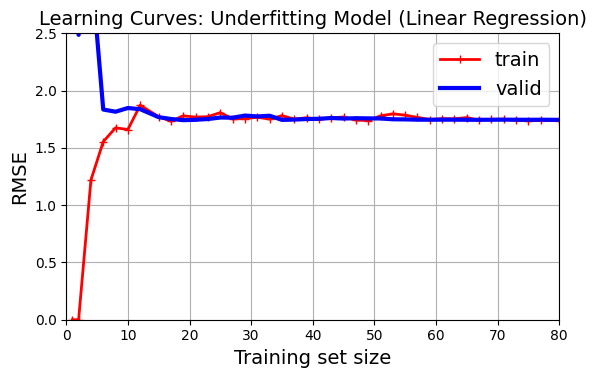

In [433]:
plt.figure(figsize=(6, 4))  # extra code – not needed, just formatting
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")

# extra code – beautifies and saves Figure 4–15
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.title("Learning Curves: Underfitting Model (Linear Regression)")
plt.grid()
plt.legend(loc="upper right")
plt.axis([0, 80, 0, 2.5])
save_fig("underfitting_learning_curves_plot")

plt.show()

This code demonstrates how to generate and analyze **learning curves** for a Linear Regression model to diagnose model performance.

### What the Code Does

```python
from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(), X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_root_mean_squared_error")
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)
```

**Key Parameters:**
- **`LinearRegression()`**: The model being evaluated (simple linear regression)
- **`train_sizes=np.linspace(0.01, 1.0, 40)`**: Tests 40 different training set sizes from 1% to 100% of available data
- **`cv=5`**: Uses 5-fold cross-validation for reliable performance estimates
- **`scoring="neg_root_mean_squared_error"`**: Uses negative RMSE as the metric (negative because sklearn treats higher scores as better)

**Outputs:**
- **`train_sizes`**: Array of training set sizes used
- **`train_scores`**: RMSE scores on training data for each size
- **`valid_scores`**: RMSE scores on validation data for each size

### Data Processing

```python
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)
```

- Converts negative RMSE back to positive values
- Takes the mean across CV folds for each training size, i.e., averages performance

### Visualization

The plot shows both training and validation errors vs. training set size:
- **Red line (`train`)**: How well the model fits the training data
- **Blue line (`valid`)**: How well the model generalizes to unseen data

### Interpreting the Results

This learning curve reveals **underfitting** characteristics:
1. **High bias**: Both training and validation errors remain relatively high
2. **Small gap**: Training and validation errors converge to similar values
3. **Plateau effect**: Adding more training data doesn't significantly improve performance

**Diagnosis**: The linear model is too simple to capture the underlying quadratic relationship in the data. The solution would be to use a more complex model (like polynomial features) rather than collecting more training data.

## Learning Curves Comparison: Linear vs Polynomial Models

This code demonstrates how learning curves can reveal different types of model behavior by comparing a simple linear model (which underfits) with a more complex polynomial model.

### What Learning Curves Show

Learning curves plot model performance (RMSE) against training set size, showing two key lines:
- **Training error**: How well the model fits the training data
- **Validation error**: How well the model generalizes to unseen data

### The Linear Model Results (Previous Cell)

The linear regression learning curves revealed **underfitting** characteristics:
- Both training and validation errors remained high (~1.75 RMSE)
- Small gap between training and validation errors
- Performance plateaued - adding more data didn't help

This happened because linear regression was too simple to capture the underlying quadratic relationship in our data (y = 0.5x² + x + 2 + noise).

### Next: Polynomial Model Analysis

The following cells will show learning curves for a 10th-degree polynomial model, which will likely demonstrate **overfitting** behavior:
- Large gap between training and validation errors
- Training error will be very low
- Validation error will be higher, especially with small training sets
- The gap should decrease as more training data is added

This comparison illustrates the bias-variance tradeoff:
- **High bias (underfitting)**: Model too simple, consistent but wrong
- **High variance (overfitting)**: Model too complex, fits training data perfectly but generalizes poorly

Learning curves help diagnose which problem you're facing and guide your next steps in model development.

In [434]:
from sklearn.pipeline import make_pipeline

polynomial_regression = make_pipeline(
    PolynomialFeatures(degree=10, include_bias=False),
    LinearRegression())

train_sizes, train_scores, valid_scores = learning_curve(
    polynomial_regression, X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_root_mean_squared_error")

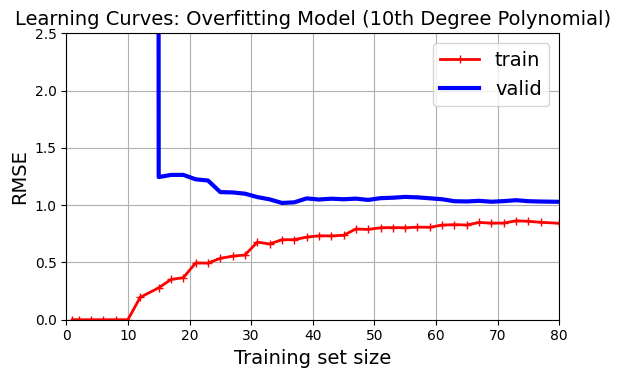

In [435]:
# extra code – generates and saves Figure 4–16

train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.legend(loc="upper right")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.title("Learning Curves: Overfitting Model (10th Degree Polynomial)")
plt.grid()
plt.axis((0, 80, 0, 2.5))
save_fig("learning_curves_plot")
plt.show()

### Polynomial Model Learning Curves Analysis

The code in the previous cells demonstrates how **polynomial regression** behaves differently from linear regression by showing their respective learning curves.

#### Polynomial Model Setup

```python
polynomial_regression = make_pipeline(
    PolynomialFeatures(degree=10, include_bias=False),
    LinearRegression())
```

The polynomial model uses a **10th-degree polynomial**, which creates a highly complex model with many features (x, x², x³, ..., x¹⁰). This allows the model to fit very complex curves to the data.

#### Learning Curves Comparison

**Linear Model (Previous Analysis):**
- **Underfitting**: Both training and validation errors remained high (~1.75 RMSE)
- **High bias**: Model too simple to capture the quadratic relationship
- **Small gap**: Training and validation errors converged, indicating consistent but poor performance

**Polynomial Model (10th Degree):**
- **Overfitting**: Large gap between training and validation errors
- **Training error**: Starts very low (near 0) and gradually increases as more data is added
- **Validation error**: Starts high (~2.8 RMSE) and gradually decreases toward training error
- **High variance**: Model complexity leads to high sensitivity to training data variations

#### Key Insights from Polynomial Learning Curves

1. **Small Training Sets**: The 10th-degree polynomial can perfectly fit small datasets (training error ≈ 0), but generalizes poorly (high validation error)

2. **Large Training Sets**: As more data is added, the gap between training and validation errors decreases, indicating better generalization

3. **Optimal Complexity**: The true data follows a quadratic relationship (degree 2), so a 10th-degree polynomial is unnecessarily complex, leading to overfitting

#### Diagnostic Value

These learning curves clearly demonstrate:
- **When to add more data**: The decreasing gap suggests more training data helps reduce overfitting
- **When to reduce model complexity**: The large initial gap indicates the model is too complex
- **Model selection guidance**: A 2nd-degree polynomial would likely show better learning curves for this quadratic dataset

This comparison illustrates the **bias-variance tradeoff** and shows how learning curves help diagnose and address model performance issues.

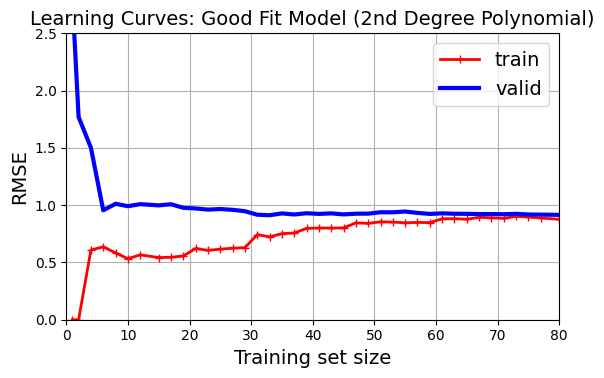

In [436]:
from sklearn.pipeline import make_pipeline

polynomial_regression = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression())

train_sizes, train_scores, valid_scores = learning_curve(
    polynomial_regression, X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_root_mean_squared_error")
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.title("Learning Curves: Good Fit Model (2nd Degree Polynomial)")
plt.grid()
plt.legend()
plt.axis((0, 80, 0, 2.5))
save_fig("good_fit_learning_curves_plot")
plt.show()

The 2nd-degree polynomial model's learning curves would likely show:
- Both training and validation errors starting lower than the linear model
- A smaller gap between training and validation errors, indicating better generalization
- Training error gradually decreasing and stabilizing at a low value
- Validation error also decreasing and stabilizing, but at a higher value than training error

---

# Regularized Linear Models

Regularized linear models *add a penalty term to the cost function* to constrain the model's parameters, helping to prevent overfitting. The main types are:

- **Ridge Regression (L2)**: Adds the sum of squared weights to the cost function. *Reduces weight magnitudes but keeps all features*.

- **Lasso Regression (L1)**: Adds the sum of absolute weight values to the cost function. Can drive some weights to exactly zero, *effectively performing feature selection*.

- **Elastic Net**: Combines both L1 and L2 penalties, offering a balance between Ridge and Lasso.

The regularization strength is controlled by the hyperparameter **α** (alpha): higher values mean stronger regularization and simpler models.

Regularization is a technique used to prevent overfitting by adding a penalty term to the model's cost function. This penalty discourages the model from learning overly complex patterns and assigning excessively large weights to its features. The `alpha` value determines the strength of this penalty.

## Ridge Regression
Ridge Regression is a regularized version of Linear Regression that adds an **L2 penalty** term to the cost function. This penalty is proportional to the sum of the squared weights, which constrains the model's parameters and helps prevent overfitting.

### Cost Function

The Ridge Regression cost function is:

**J(θ) = MSE(θ) + α × (1/2) × Σθᵢ²**

Where:
- **MSE(θ)**: Mean Squared Error (the standard linear regression loss)
- **α × (1/2) × Σθᵢ²**: L2 regularization term
    - **α**: Regularization hyperparameter controlling the strength of regularization. It determines how much to penalize large weights.
        - **α = 0**: No regularization (equivalent to standard linear regression)
        - **α → ∞**: Weights approach zero, leading to a constant model     
    - **Σθᵢ²**: Sum of squared weights (excluding the bias term θ₀). A model with large weights will incur a higher penalty.

### Key Characteristics

**Regularization Effect:**
- Penalizes large weight values, keeping them small
- Forces the model to be simpler and more generalizable
    - Reduces overfitting, especially in high-dimensional datasets
    - Encourages weight shrinkage, but not sparsity
    - Provides a closed-form solution for linear problems
- Unlike Lasso, Ridge **never eliminates features** completely (weights approach but never reach zero)

**Hyperparameter α:**
- **α = 0**: Standard linear regression (no regularization)
- **α → ∞**: Weights approach zero, model becomes constant
- **Optimal α**: Found through cross-validation

**When to Use Ridge:**
- When you have **multicollinearity** (highly correlated features)
- When you want to keep all features but reduce their impact
- When you need a stable, interpretable model
- As a default regularization choice for linear models

### Comparison to Other Methods

- **vs. Linear Regression**: Ridge is more robust to overfitting
- **vs. Lasso**: Ridge doesn't perform feature selection; all features remain
- **vs. Elastic Net**: Ridge uses only L2 penalty, while Elastic Net combines L1 and L2

Ridge Regression is particularly effective when dealing with high-dimensional datasets where feature relationships matter, and you want to preserve all features while controlling model complexity.

Let's generate a very small and noisy linear dataset:

In [437]:
# extra code – we've done this type of generation several times before
np.random.seed(42)
m = 20
X = 3 * np.random.rand(m, 1) # values in the range [0, 3)
# y = 1 + 0.5 * X + Gaussian noise
y = 1 + 0.5 * X + np.random.randn(m, 1) / 1.5
X_new = np.linspace(0, 3, 100).reshape(100, 1)

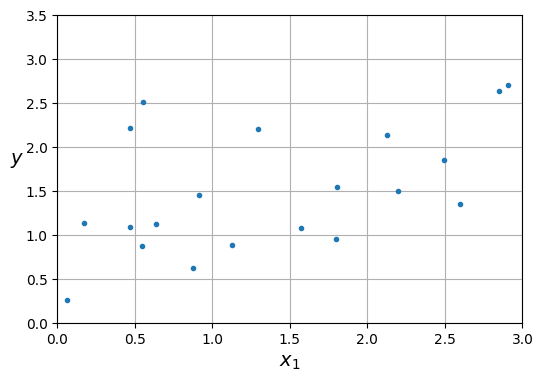

In [438]:
# extra code – a quick peek at the dataset we just generated
plt.figure(figsize=(6, 4))
plt.plot(X, y, ".")
plt.xlabel("$x_1$")
plt.ylabel("$y$  ", rotation=0)
plt.axis([0, 3, 0, 3.5])
plt.grid()
plt.show()

In [439]:
from sklearn.linear_model import Ridge

ridge_reg = Ridge(alpha=0.1, solver="cholesky")
ridge_reg.fit(X, y)

sample_data = [[1.5],[2.6]]
print(f'Type of sample_data: {type(sample_data)}')
sample_data_array = np.array(sample_data)
print(f'Shape of sample_data after conversion: {sample_data_array.shape}')
ridge_reg.predict(sample_data_array)

Type of sample_data: <class 'list'>
Shape of sample_data after conversion: (2, 1)


array([[1.55325833],
       [1.97439289]])

### Ridge Regression Implementation with Scikit-Learn

This code demonstrates how to use **Ridge Regression** from Scikit-Learn to fit a regularized linear model to the small, noisy dataset.

**1. Import Ridge Regressor:**
- `from sklearn.linear_model import Ridge`: Imports the Ridge Regression class

**2. Create Ridge Model:**
- `Ridge(alpha=0.1, solver="cholesky")`: Instantiates a Ridge Regression model with:
    - **`alpha=0.1`**: Regularization strength parameter (α)
        - Controls how much to penalize large weights
        - Smaller values = less regularization (closer to standard linear regression)
        - Larger values = more regularization (simpler model, smaller weights)
    - **`solver="cholesky"`**: Algorithm used to compute the Ridge solution
        - Fast and efficient for small to medium datasets
        - Uses *Cholesky decomposition* to solve the normal equations
        - Other solvers include `"lsqr"`, `"saga"`, `"svd"`, etc.

**3. Train the Model:**
- `ridge_reg.fit(X, y)`: Trains the Ridge Regression model on the training data
    - Learns the optimal weights (coefficients) that minimize the regularized cost function
    - The L2 penalty keeps weights small, preventing overfitting

**4. Make Predictions:**
- `ridge_reg.predict([[1.5]])`: Predicts the target value for x = 1.5
    - Returns the model's prediction based on the learned parameters
    - Should return a value close to the true relationship (y = 1 + 0.5×1.5 = 1.75)

#### Why Use Ridge Here?

With only 20 noisy data points, a standard linear regression model could easily overfit. Ridge regression's L2 penalty constrains the model parameters, leading to better generalization on unseen data. The relatively small `alpha=0.1` provides moderate regularization suitable for this simple linear relationship.

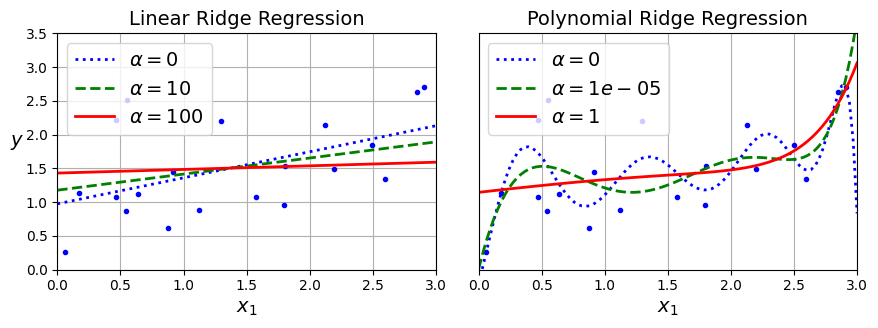

In [440]:
# extra code – this cell generates and saves Figure 4–17

def plot_model(model_class, polynomial, alphas, **model_kwargs):
    plt.plot(X, y, "b.", linewidth=3)
    for alpha, style in zip(alphas, ("b:", "g--", "r-")):
        # if alpha > 0:
        #     model = model_class(alpha, **model_kwargs)
        # else:
        #     model = LinearRegression()
        model = model_class(alpha, **model_kwargs)
        if polynomial: # polynomial features + standardization
            model = make_pipeline(
                PolynomialFeatures(degree=10, include_bias=False),
                StandardScaler(),
                model)
            plt.title(f"Polynomial {model_class.__name__} Regression")
        else: # plain linear model
            plt.title(f"Linear {model_class.__name__} Regression")
        model.fit(X, y)
        y_new_regul = model.predict(X_new)
        plt.plot(X_new, y_new_regul, style, linewidth=2,
                 label=fr"$\alpha = {alpha}$")
    plt.legend(loc="upper left")
    plt.xlabel("$x_1$")
    plt.axis((0, 3, 0, 3.5))
    plt.grid()

plt.figure(figsize=(9, 3.5))
plt.subplot(121)
plot_model(Ridge, polynomial=False, alphas=(0, 10, 100), random_state=42)
plt.ylabel("$y$  ", rotation=0)
plt.subplot(122)
plot_model(Ridge, polynomial=True, alphas=(0, 10**-5, 1), random_state=42)
plt.yticks([])  # hide y axis labels on the right plot
save_fig("ridge_regression_plot")
plt.show()

### Visualizing Ridge Regression with Different Regularization Strengths

This code generates Figure 4-17, which compares Ridge Regression models with different regularization strengths (α values) on both linear and polynomial features.

#### The `plot_model()` Function

This helper function creates comparative plots showing how different α values affect model predictions:

**Parameters:**
- **`model_class`**: The regression class to use (Ridge in this case)
- **`polynomial`**: Boolean flag - whether to add polynomial features
- **`alphas`**: Tuple of α values to compare (e.g., (0, 10, 100))
- **`**model_kwargs`**: Additional arguments passed to the model

**Workflow:**
1. Plots the original training data as blue dots
2. Iterates through three α values, creating a model for each
3. For each α:
    - If `alpha > 0`: Creates a Ridge model with that α
    - If `alpha = 0`: Uses standard LinearRegression (no regularization)
    - If `polynomial=True`: Wraps the model in a pipeline with 10th-degree polynomial features and standardization
4. Fits each model and plots predictions with different line styles

#### Two-Subplot Comparison

**Left Plot (`plt.subplot(121)`):**
- **Linear Ridge Regression** on the original features
- Compares α = 0 (no regularization), α = 10, and α = 100
- Shows how regularization affects the slope and intercept of a simple linear model
- With small dataset (20 points), even linear models benefit from regularization

**Right Plot (`plt.subplot(122)`):**
- **Polynomial Ridge Regression** with 10th-degree features
- Compares α = 0, α = 10⁻⁵, and α = 1
- Demonstrates Ridge's power in preventing polynomial overfitting
- Without regularization (α = 0), the 10th-degree polynomial would wildly overfit
- Higher α values produce smoother, more generalizable curves

#### Key Insights

**Regularization Effect:**
- **α = 0**: No penalty, model can overfit (especially with polynomial features)
- **Small α** (10⁻⁵): Light regularization, model remains flexible
- **Large α** (1, 10, 100): Strong regularization, model becomes simpler and smoother

**Why StandardScaler is Used:**
- Polynomial features create vastly different scales (x, x², x³, ..., x¹⁰)
- Ridge penalty treats all features equally, so scaling is crucial
- StandardScaler ensures fair regularization across all features

**Visual Pattern:**
- Blue dotted line (α = 0): Most flexible, potential overfitting
- Green dashed line (moderate α): Balanced fit
- Red solid line (high α): Smoothest, most regularized

This visualization clearly demonstrates how Ridge regression controls model complexity through the α hyperparameter, with the optimal value depending on the specific dataset and feature complexity.

### Ridge Regression with Stochastic Gradient Descent

This code implements Ridge Regression using `SGDRegressor` with stochastic gradient descent, an alternative approach to the closed-form solution.

**Key Parameters:**
- **`penalty="l2"`**: Applies L2 regularization (Ridge)
- **`alpha=0.1 / m`**: Regularization strength normalized by dataset size (equivalent to α=0.1 in Ridge)
- **`tol=None`**: Disables early stopping based on loss improvement
- **`max_iter=1000`**: Runs for 1000 epochs
- **`eta0=0.01`**: Initial learning rate

**Note:** SGD's `alpha` is scaled differently than Ridge's `alpha`. To match `Ridge(alpha=0.1)`, we use `alpha=0.1/m` in SGDRegressor.

This approach is useful for very large datasets where computing the closed-form solution becomes computationally expensive.

In [441]:
sgd_reg = SGDRegressor(penalty="l2", alpha=0.1 / m, tol=None,
                       max_iter=1000, eta0=0.01, random_state=42)
sgd_reg.fit(X, y.ravel())  # y.ravel() because fit() expects 1D targets
sgd_reg.predict(sample_data_array)

array([1.55302613, 1.97617761])

In [442]:
# extra code – show that we get roughly the same solution as earlier when
#              we use Stochastic Average GD (solver="sag")
ridge_reg = Ridge(alpha=0.1, solver="sag", random_state=42)
ridge_reg.fit(X, y)
ridge_reg.predict(sample_data_array)

array([[1.55326019],
       [1.97441083]])

An alternative solver for Ridge Regression using **Stochastic Average Gradient Descent (SAG)**, which is more efficient for large datasets than the Cholesky solver used earlier.

**Key Points:**
- **`solver="sag"`**: Uses *Stochastic Average Gradient Descent*, an iterative optimization algorithm
- **Same α value (0.1)**: Maintains the same regularization strength as the Cholesky-based Ridge model
- **Equivalent results**: Produces nearly identical predictions to previous Ridge implementations

**When to use SAG:**
- Large datasets where computing the *closed-form solution (Cholesky)* is expensive
- When you need faster training on datasets with many samples
- SAG converges faster than standard SGD by *maintaining a memory of past gradients*

The prediction for x = 1.5 should be very close to the previous Ridge and SGD results, confirming that all three approaches solve the same Ridge regression problem.

### Closed-form Ridge Regression (manual NumPy)

This section computes the Ridge solution directly with the normal equation:

- Formula: θ_ridge = (X_bᵀ X_b + α A)⁻¹ X_bᵀ y
- X_b augments X with a bias term (x₀ = 1) so the intercept is learned
- A is the penalty matrix that does not penalize the bias term

Where A is:
- A = I with the top-left entry set to 0
- Shape: (n_features + 1, n_features + 1), matching the number of columns in X_b
- Concretely: A = diag([0, 1, 1, …, 1])

Notes:
- Use add_dummy_feature(X) to build X_b and add_dummy_feature(X_new) for predictions
- α controls regularization strength and is consistent with Ridge(alpha=α) in scikit-learn
- np.linalg.inv is used here for clarity, though np.linalg.solve is numerically preferred

In [443]:
# extra code – shows the closed form solution of Ridge regression,
#              compare with the next Ridge model's learned parameters below
alpha = 0.1
A = np.array([[0., 0.], [0., 1.]])
X_b = np.c_[np.ones(m), X]
closed_form_ridge_solution = np.linalg.inv(X_b.T @ X_b + alpha * A) @ X_b.T @ y
print(f'Closed-form solution of Ridge regression:\n{closed_form_ridge_solution}')

Closed-form solution of Ridge regression:
[[0.97898394]
 [0.3828496 ]]


Compare the closed-form solution's parameters and predictions to those from scikit-learn's Ridge implementation to confirm correctness.

First, the parameters from scikit-learn's Ridge model are shown: 

In [444]:
ridge_reg.intercept_, ridge_reg.coef_  # extra code

(array([0.97896386]), array([[0.38286422]]))

Then, we use the closed-form solution to compute the prediction for `sample_data_array`:

In [445]:
closed_form_ridge_predictions = np.c_[np.ones((sample_data_array.shape[0], 1)), sample_data_array] @ closed_form_ridge_solution
print(f'Closed-form Ridge predictions:\n{closed_form_ridge_predictions}')

Closed-form Ridge predictions:
[[1.55325833]
 [1.97439289]]


---

## Lasso Regression

Lasso Regression is a regularized version of Linear Regression that adds an **L1 penalty** term to the cost function. This penalty is proportional to the sum of the absolute values of the weights, which encourages sparsity in the model parameters and can lead to feature selection.

### Cost Function

The Lasso Regression cost function is:

**J(θ) = MSE(θ) + α × Σ|θᵢ|**

Where:
- **MSE(θ)**: Mean Squared Error (the standard linear regression loss)
- **α × Σ|θᵢ|**: L1 regularization term
    - **α**: Regularization hyperparameter controlling the strength of regularization
        - **α = 0**: No regularization (equivalent to standard linear regression)
        - **α → ∞**: Weights approach zero, leading to a constant model
    - **Σ|θᵢ|**: Sum of absolute weights (excluding the bias term θ₀). Penalizes the absolute magnitude of weights.

### Key Characteristics

**Sparsity Effect:**
- Encourages some weights to become exactly zero, effectively performing **automatic feature selection**
- Results in simpler, more interpretable models
- Particularly useful when you suspect that many features are irrelevant
- Unlike Ridge, Lasso can completely eliminate features from the model

**Hyperparameter α:**
- **α = 0**: Standard linear regression (no regularization)
- **α → ∞**: All weights approach zero, model becomes constant
- **Optimal α**: Found through cross-validation

**When to Use Lasso:**
- When you want to perform **feature selection** and identify the most important predictors
- When you have high-dimensional data with many features, but suspect only a few are truly relevant
- When you want a simpler, more interpretable model with fewer features
- When you need to reduce model complexity and improve generalization

### Comparison to Other Methods

- **vs. Linear Regression**: Lasso is more robust to overfitting and automatically selects features
- **vs. Ridge**: Lasso can eliminate features entirely (weights = 0), while Ridge only shrinks weights toward zero
- **vs. Elastic Net**: Lasso uses only L1 penalty, while Elastic Net combines both L1 and L2 penalties

Lasso Regression is particularly effective when dealing with high-dimensional datasets where feature selection is important, as it can automatically identify and retain only the most relevant features for prediction.

In [446]:
from sklearn.linear_model import Lasso

lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, y)
lasso_reg.predict(sample_data_array)

array([1.53788174, 1.82572108])

It shows how to use **Lasso Regression** with Scikit-Learn to fit a regularized linear model to the dataset. 

- `Lasso(alpha=0.1)` creates a Lasso regression model with regularization strength α=0.1.
- `.fit(X, y)` trains the model on the data, learning weights that may be set exactly to zero (feature selection).
- `.predict(sample_data_array)` predicts the target value for the provided sample data using the trained model.

Lasso encourages sparsity in the model coefficients, making it useful for feature selection.

In [447]:
lasso_reg.intercept_, lasso_reg.coef_

(array([1.14537356]), array([0.26167212]))

c:\Users\yuanh\Box\tech\Python\side_projects\HOML\handson-ml3\.venv\Lib\site-packages\sklearn\base.py:1152: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\yuanh\Box\tech\Python\side_projects\HOML\handson-ml3\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\yuanh\Box\tech\Python\side_projects\HOML\handson-ml3\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.446e+00, tolerance: 9.295e-04 Linear regression models with null weight for the l1 regularization term are more effici

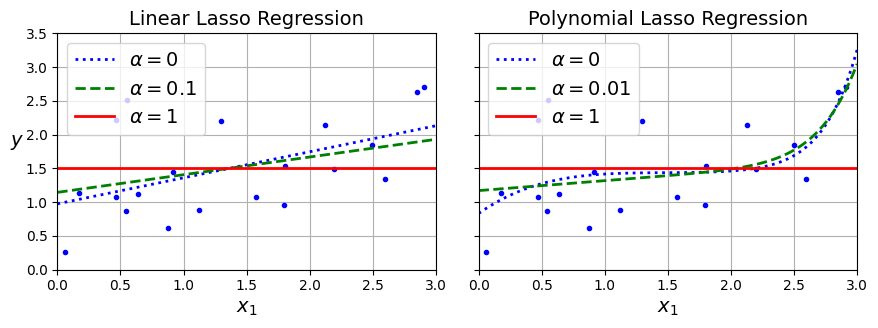

In [448]:
# extra code – this cell generates and saves Figure 4–18
plt.figure(figsize=(9, 3.5))
plt.subplot(121)
plot_model(Lasso, polynomial=False, alphas=(0, 0.1, 1), random_state=42)
plt.ylabel("$y$  ", rotation=0)
plt.subplot(122)
plot_model(Lasso, polynomial=True, alphas=(0, 1e-2, 1), random_state=42)
plt.gca().axes.yaxis.set_ticklabels([])
save_fig("lasso_regression_plot")
plt.show()

This code generates Figure 4-18, comparing **Lasso Regression** models with different regularization strengths (α values) on both linear and polynomial features.

### What the Code Does

- Uses the `plot_model()` function to visualize how Lasso regularization affects model predictions.
- **Left subplot:** Fits Lasso models (α = 0, 0.1, 1) on the original linear features.
- **Right subplot:** Fits Lasso models (α = 0, 0.01, 1) on 10th-degree polynomial features (with standardization).
- For each α value, the model is trained and its predictions are plotted with different line styles.

### Key Insights

- **α = 0:** No regularization, equivalent to standard linear regression (can overfit, especially with polynomials).
- **Increasing α:** Lasso penalizes large coefficients and can set some to exactly zero, performing feature selection and producing simpler, smoother curves.
- **Polynomial features:** Lasso helps prevent overfitting by shrinking or eliminating unnecessary polynomial terms.

This visualization shows how Lasso regression controls model complexity and encourages sparsity, especially useful when dealing with high-dimensional data or when feature selection is desired.

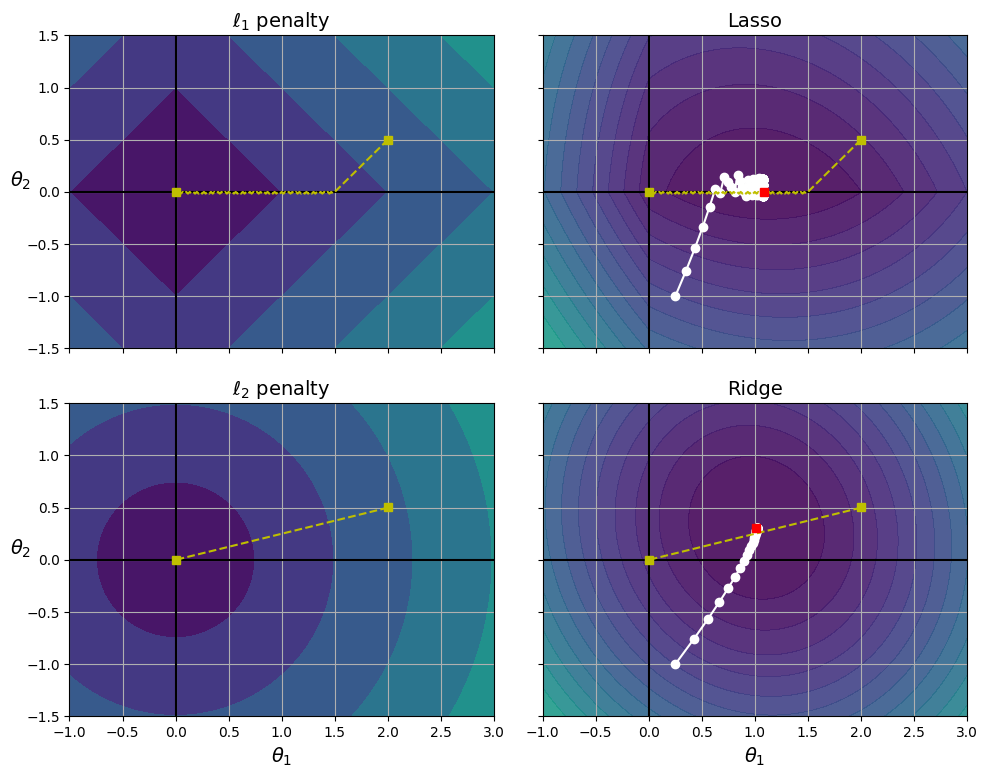

In [449]:
# extra code – this BIG cell generates and saves Figure 4–19

t1a, t1b, t2a, t2b = -1, 3, -1.5, 1.5

t1s = np.linspace(t1a, t1b, 500)
t2s = np.linspace(t2a, t2b, 500)
t1, t2 = np.meshgrid(t1s, t2s)
T = np.c_[t1.ravel(), t2.ravel()]
Xr = np.array([[1, 1], [1, -1], [1, 0.5]])
yr = 2 * Xr[:, :1] + 0.5 * Xr[:, 1:]

J = (1 / len(Xr) * ((T @ Xr.T - yr.T) ** 2).sum(axis=1)).reshape(t1.shape)

N1 = np.linalg.norm(T, ord=1, axis=1).reshape(t1.shape)
N2 = np.linalg.norm(T, ord=2, axis=1).reshape(t1.shape)

t_min_idx = np.unravel_index(J.argmin(), J.shape)
t1_min, t2_min = t1[t_min_idx], t2[t_min_idx]

t_init = np.array([[0.25], [-1]])

def bgd_path(theta, X, y, l1, l2, core=1, eta=0.05, n_iterations=200):
    path = [theta]
    for iteration in range(n_iterations):
        gradients = (core * 2 / len(X) * X.T @ (X @ theta - y)
                     + l1 * np.sign(theta) + l2 * theta)
        theta = theta - eta * gradients
        path.append(theta)
    return np.array(path)

fig, axes = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(10.1, 8))

for i, N, l1, l2, title in ((0, N1, 2.0, 0, "Lasso"), (1, N2, 0, 2.0, "Ridge")):
    JR = J + l1 * N1 + l2 * 0.5 * N2 ** 2

    tr_min_idx = np.unravel_index(JR.argmin(), JR.shape)
    t1r_min, t2r_min = t1[tr_min_idx], t2[tr_min_idx]

    levels = np.exp(np.linspace(0, 1, 20)) - 1
    levelsJ = levels * (J.max() - J.min()) + J.min()
    levelsJR = levels * (JR.max() - JR.min()) + JR.min()
    levelsN = np.linspace(0, N.max(), 10)

    path_J = bgd_path(t_init, Xr, yr, l1=0, l2=0)
    path_JR = bgd_path(t_init, Xr, yr, l1, l2)
    path_N = bgd_path(theta=np.array([[2.0], [0.5]]), X=Xr, y=yr,
                      l1=np.sign(l1) / 3, l2=np.sign(l2), core=0)
    ax = axes[i, 0]
    ax.grid()
    ax.axhline(y=0, color="k")
    ax.axvline(x=0, color="k")
    ax.contourf(t1, t2, N / 2.0, levels=levelsN)
    ax.plot(path_N[:, 0], path_N[:, 1], "y--")
    ax.plot(0, 0, "ys")
    ax.plot(t1_min, t2_min, "ys")
    ax.set_title(fr"$\ell_{i + 1}$ penalty")
    ax.axis([t1a, t1b, t2a, t2b])
    if i == 1:
        ax.set_xlabel(r"$\theta_1$")
    ax.set_ylabel(r"$\theta_2$", rotation=0)

    ax = axes[i, 1]
    ax.grid()
    ax.axhline(y=0, color="k")
    ax.axvline(x=0, color="k")
    ax.contourf(t1, t2, JR, levels=levelsJR, alpha=0.9)
    ax.plot(path_JR[:, 0], path_JR[:, 1], "w-o")
    ax.plot(path_N[:, 0], path_N[:, 1], "y--")
    ax.plot(0, 0, "ys")
    ax.plot(t1_min, t2_min, "ys")
    ax.plot(t1r_min, t2r_min, "rs")
    ax.set_title(title)
    ax.axis([t1a, t1b, t2a, t2b])
    if i == 1:
        ax.set_xlabel(r"$\theta_1$")

save_fig("lasso_vs_ridge_plot")
plt.show()

### Lasso vs Ridge Regularization Visualization
This code generates Figure 4-19, which visually compares the effects of **Lasso (L1)** and **Ridge (L2)** regularization on linear regression parameter space.

#### What the Code Does

- **Creates a synthetic regression problem** with two parameters (θ₁, θ₂) and three data points.
- **Computes the cost function surface** (Mean Squared Error) over a grid of θ₁ and θ₂ values.
- **Adds L1 (Lasso) and L2 (Ridge) penalties** to the cost function to show how regularization changes the optimization landscape.
- **Plots contours** for:
    - The penalty term alone (left column: $\ell_1$ for Lasso, $\ell_2$ for Ridge)
    - The regularized cost function (right column: Lasso and Ridge)
- **Simulates gradient descent paths** showing how parameters are updated under each penalty.

#### Key Visualization Elements

- **Left column:** Shows the geometry of the L1 (diamond-shaped) and L2 (circular) penalty surfaces.
- **Right column:** Shows the regularized cost function (MSE + penalty) and the path taken by gradient descent to reach the minimum.
- **Yellow dashed line:** Path of gradient descent on the penalty surface alone.
- **White line with circles:** Path of gradient descent on the regularized cost function.
- **Yellow and red squares:** Locations of the minimum for the unregularized and regularized cost functions.

#### Insights

- **Lasso (L1):** The penalty surface has sharp corners, encouraging some parameters to become exactly zero (feature selection).
- **Ridge (L2):** The penalty surface is smooth and round, shrinking parameters but rarely setting them to zero.
- **Gradient descent paths:** Show how regularization changes the trajectory and final values of the parameters.

This figure helps illustrate the fundamental difference between Lasso and Ridge regularization: Lasso can produce sparse solutions, while Ridge produces smooth shrinkage of all parameters.

---
## Elastic Net
Elastic Net is a regularized linear regression model that combines both **L1 (Lasso)** and **L2 (Ridge)** penalties in its cost function. This allows Elastic Net to benefit from the strengths of both methods: it can shrink coefficients (like Ridge) and perform feature selection (like Lasso).

### Cost Function

**J(θ) = MSE(θ) + α × (r × Σ|θᵢ| + (1 - r) × ½ Σθᵢ²)**

Where:
- **MSE(θ)**: Mean Squared Error
- **α**: Regularization strength
- **r**: Mixing ratio between L1 and L2 penalties (`l1_ratio` in scikit-learn)
    - `r = 1`: Equivalent to Lasso
    - `r = 0`: Equivalent to Ridge
    - `0 < r < 1`: Mix of both

### Key Characteristics

- **Feature selection**: Can set some coefficients to zero (like Lasso)
- **Stability**: Handles correlated features better than Lasso alone
- **Flexibility**: The `l1_ratio` hyperparameter lets you control the balance between L1 and L2 regularization

### When to Use Elastic Net

- When you have many features and expect some to be irrelevant
- When features are highly correlated
- When you want a balance between Ridge and Lasso behaviors

Elastic Net is often preferred over pure Lasso or Ridge when working with high-dimensional datasets, as it tends to perform better in practice by combining their advantages.

In [450]:
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(X, y)
elastic_net.predict(sample_data_array)

array([1.54333232, 1.87842113])

This code demonstrates how to use **Elastic Net Regression** with Scikit-Learn to fit a regularized linear model to the dataset.

- `ElasticNet(alpha=0.1, l1_ratio=0.5)` creates an Elastic Net regression model with regularization strength α=0.1 and an equal mix of L1 (Lasso) and L2 (Ridge) penalties (`l1_ratio=0.5`).
- `.fit(X, y)` trains the model on the data, learning weights that are both shrunk and potentially set to zero.
- `.predict(sample_data_array)` predicts the target value for the provided sample data using the trained model.

Elastic Net combines the benefits of Ridge and Lasso, making it useful for feature selection and handling correlated features.

In [451]:
elastic_net.intercept_, elastic_net.coef_

(array([1.08639303]), array([0.30462619]))

---

## Early Stopping

Let's go back to the quadratic dataset we used earlier:

**Warning**: In recent versions of Scikit-Learn, you must use `root_mean_squared_error()` to compute the RMSE, instead of `mean_squared_error(labels, predictions, squared=False)`. The following `try`/`except` block tries to import `root_mean_squared_error`, and if it fails it just defines it.

In [452]:
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error

    def root_mean_squared_error(labels, predictions):
        return mean_squared_error(labels, predictions, squared=False)

Shape of X_train: (50, 1), Shape of y_train: (50,)
Shape of X_valid: (50, 1), Shape of y_valid: (50,)


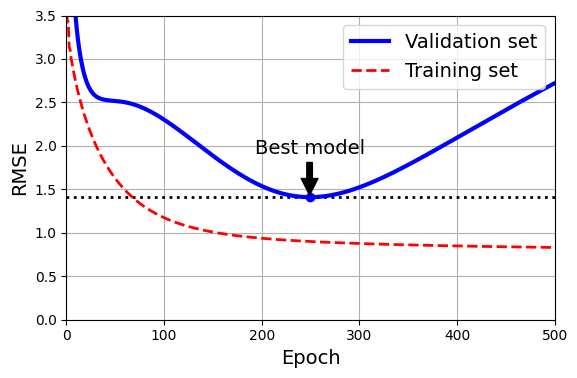

In [453]:
from copy import deepcopy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# extra code – creates the same quadratic dataset as earlier and splits it
np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)
# X_train, y_train = X[: m // 2], y[: m // 2, 0]
# X_valid, y_valid = X[m // 2 :], y[m // 2 :, 0]
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.5, shuffle=False)
y_train = y_train.ravel()  # make y 1D array
y_valid = y_valid.ravel()  # make y 1D array
print(f'Shape of X_train: {X_train.shape}, Shape of y_train: {y_train.shape}')
print(f'Shape of X_valid: {X_valid.shape}, Shape of y_valid: {y_valid.shape}')

preprocessing = make_pipeline(PolynomialFeatures(degree=90, include_bias=False),
                              StandardScaler())
X_train_prep = preprocessing.fit_transform(X_train)
X_valid_prep = preprocessing.transform(X_valid)
sgd_reg = SGDRegressor(penalty=None, eta0=0.002, random_state=42)
n_epochs = 500
best_valid_rmse = float('inf')
train_errors, val_errors = [], []  # extra code – it's for the figure below
best_model = None
initial_model = None

for epoch in range(n_epochs):
    sgd_reg.partial_fit(X_train_prep, y_train)
    y_valid_predict = sgd_reg.predict(X_valid_prep)
    val_error = root_mean_squared_error(y_valid, y_valid_predict)
    if val_error < best_valid_rmse: # early stopping condition
        best_valid_rmse = val_error
        best_model = deepcopy(sgd_reg) # save the best model found so far
    if epoch == 0:
        initial_model = deepcopy(sgd_reg) # save the initial model
        
    # extra code – we evaluate the train error and save it for the figure
    y_train_predict = sgd_reg.predict(X_train_prep)
    train_error = root_mean_squared_error(y_train, y_train_predict)
    val_errors.append(val_error) # save validation error for the figure
    train_errors.append(train_error) # save training error for the figure

# extra code – this section generates and saves Figure 4–20
best_epoch = np.argmin(val_errors) # epoch with the best validation RMSE
plt.figure(figsize=(6, 4))
plt.annotate('Best model',
             xy=(best_epoch, best_valid_rmse),
             xytext=(best_epoch, best_valid_rmse + 0.5),
             ha="center",
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.plot([0, n_epochs], [best_valid_rmse, best_valid_rmse], "k:", linewidth=2) # horizontal line for best valid RMSE
plt.plot(val_errors, "b-", linewidth=3, label="Validation set") # plot validation errors
plt.plot(best_epoch, best_valid_rmse, "bo") # highlight best model
plt.plot(train_errors, "r--", linewidth=2, label="Training set") # plot training errors
plt.legend(loc="upper right")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.axis((0, n_epochs, 0, 3.5))
plt.grid()
save_fig("early_stopping_plot")
plt.show()

**Early stopping** is a regularization technique that prevents overfitting by stopping training when validation performance stops improving.

### Dataset Preparation

The code reuses the quadratic dataset from earlier and splits it into training and validation sets:
- **Training set**: First 50 instances
- **Validation set**: Last 50 instances

### Preprocessing Pipeline

A preprocessing pipeline is created using:
- **`PolynomialFeatures(degree=90)`**: Creates polynomial features up to degree 90 (intentionally high to create potential for overfitting)
- **`StandardScaler()`**: Standardizes features to have mean=0 and variance=1

### Training Loop with Early Stopping

The code trains an `SGDRegressor` for 500 epochs, implementing early stopping manually:

1. **`sgd_reg.partial_fit()`**: Updates the model incrementally (one epoch at a time)
2. **Validation Error Calculation**: After each epoch, computes RMSE on the validation set
3. **Best Model Tracking**: 
    - If validation error improves, saves the current model using `deepcopy()`
    - This preserves the best model even if training continues and overfitting occurs
4. **Error Recording**: Stores both training and validation errors for visualization

### Key Concepts

**Why Early Stopping Works:**
- Training error continuously decreases as the model learns; this indicates better fit to training data.
- Validation error typically decreases initially but starts to increase once the model begins to overfit the training data.
- By stopping training when validation error is lowest, we capture the model that generalizes best to unseen data.

**The Figure (4-20):**
- **Red dashed line**: Training error (continuously decreasing)
- **Blue solid line**: Validation error (U-shaped curve)
- **Annotation**: Marks the epoch with the best validation RMSE
- **Horizontal dotted line**: Shows the best validation error achieved

This visualization clearly shows the "sweet spot" where the model has learned enough to perform well but hasn't yet overfit to the training data.

In [454]:
print(f'Shape of best model coefficients: {best_model.coef_.shape}')
print(f'Number of non-zero coefficients in best model: {np.sum(best_model.coef_ != 0)}')
print(f'\n{best_model.intercept_}, \n{best_model.coef_}')


Shape of best model coefficients: (90,)
Number of non-zero coefficients in best model: 90

[3.0874158], 
[ 7.70613958e-01  7.73955364e-01  3.63751036e-01  4.79272450e-01
  1.84176921e-01  2.97766535e-01  9.56101662e-02  1.82261427e-01
  4.67357047e-02  1.05751742e-01  1.76613875e-02  5.32971528e-02
 -4.76288524e-04  1.66539845e-02 -1.21091122e-02 -8.99764867e-03
 -1.96409508e-02 -2.67063333e-02 -2.44558518e-02 -3.85443598e-02
 -2.73920131e-02 -4.59977380e-02 -2.89822764e-02 -5.01692203e-02
 -2.95821673e-02 -5.18933318e-02 -2.94403208e-02 -5.18079204e-02
 -2.87382355e-02 -5.04025286e-02 -2.76132850e-02 -4.80531709e-02
 -2.61724183e-02 -4.50483255e-02 -2.45006020e-02 -4.16087756e-02
 -2.26662387e-02 -3.79029077e-02 -2.07248111e-02 -3.40585506e-02
 -1.87214555e-02 -3.01721430e-02 -1.66928646e-02 -2.63158286e-02
 -1.46687517e-02 -2.25429432e-02 -1.26730142e-02 -1.88922577e-02
 -1.07246792e-02 -1.53912606e-02 -8.83868565e-03 -1.20587008e-02
 -7.02653862e-03 -8.90656128e-03 -5.29686019e-03 -

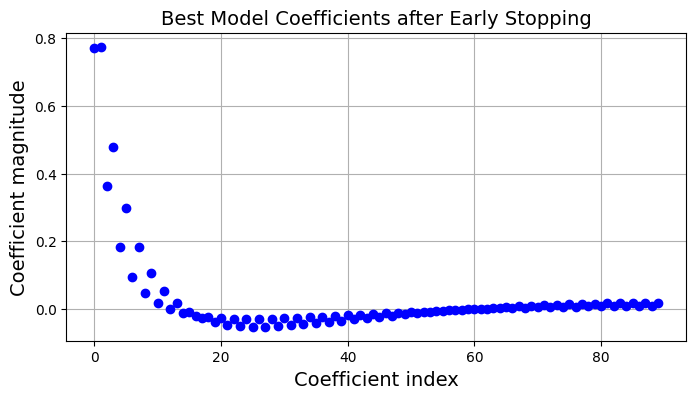

In [455]:
# Plot the coefficients of the best model
plt.figure(figsize=(8, 4))
plt.plot(best_model.coef_, "bo")
plt.xlabel("Coefficient index")
plt.ylabel("Coefficient magnitude")
plt.title("Best Model Coefficients after Early Stopping")
plt.grid()
plt.show()

The plot of the best model's coefficients shows the polynomial function learned by the model at the point of optimal validation performance. The high-degree polynomial captures the underlying quadratic relationship without overfitting, thanks to early stopping. As it can be seen, the high-order coefficients are small, indicating that the model has not overfit the noise in the training data.

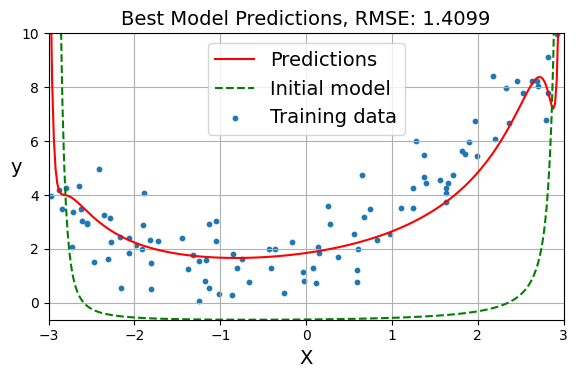

In [456]:
# Generate smooth predictions from the best early-stopped model

# 1) Create a dense grid of x-values for a smooth curve
from matplotlib.pyplot import plot


X_new = np.linspace(-3, 3, 300).reshape(300, 1)

# 2) Apply the same preprocessing used during training
X_new_prep = preprocessing.transform(X_new)

# 3) Predict with the best model selected by early stopping
y_best = best_model.predict(X_new_prep)
# Predict with the initial model for comparison
y_ini = initial_model.predict(X_new_prep)

# 4) Plot predictions vs. training data
plt.figure(figsize=(6, 4))
plt.plot(X_new, y_best, "r-", label="Predictions")
plt.plot(X_new, y_ini, "g--", label="Initial model") # optional: plot initial model
plt.scatter(X, y, s=10, label="Training data")
plt.xlabel("X")
plt.ylabel("y", rotation=0)
plt.axis((-3, 3, min(y_best.min(), y_ini.min(), y.min()), 10))
plt.title("Best Model Predictions, RMSE: {:.4f}".format(best_valid_rmse))  # use existing best_valid_rmse
plt.legend()
plt.grid()
save_fig("early_stopping_predictions_plot")
plt.show()

**Key Insights from the Coefficient Plot**

- **Sparse High-Degree Coefficients:** Most coefficients corresponding to higher-degree polynomial terms are close to zero. This indicates that the model has not overfit the noise in the training data, despite the potential for extreme flexibility with 90-degree polynomial features.
- **Dominant Low-Degree Terms:** The largest coefficients are typically associated with the lower-degree terms (e.g., linear and quadratic), which capture the true underlying relationship in the data.
- **Early Stopping Effect:** By monitoring validation error and stopping training at the optimal epoch, the model avoids learning spurious patterns from the noise, resulting in a simpler and more generalizable solution.
- **Model Interpretability:** The plot provides a clear visual indication of which polynomial terms are contributing to the model's predictions, helping to interpret the learned function.

**Conclusion:**  
Early stopping acts as an effective regularization technique, especially when using models with many parameters. It prevents overfitting by selecting the model with the best validation performance, leading to a solution where only the most relevant features have significant coefficients.

---
**Detailed Explanation of the Prediction Plot Code**

Then, we plot a smooth prediction curve from the best model found via early stopping:

1. **Dense Grid for Visualization:**  
    `X_new = np.linspace(-3, 3, 300).reshape(300, 1)` creates a fine-grained set of input values, ensuring the resulting prediction curve is smooth and reveals subtle model characteristics.

2. **Consistent Preprocessing:**  
    `X_new_prep = preprocessing.transform(X_new)` applies the exact same polynomial feature expansion and scaling as used during training. This consistency is crucial—any mismatch in preprocessing between training and prediction can lead to misleading results.

3. **Best Model Selection:**  
    `y_best = best_model.predict(X_new_prep)` uses the model parameters from the epoch with the lowest validation error, not just the final epoch. This means the predictions reflect the model's optimal generalization, not its best fit to the training data.

4. **Initial Model Comparison:**  
    `y_ini = initial_model.predict(X_new_prep)` generates predictions from the model after just the first epoch, providing a baseline to visualize how much the model has learned through training.

5. **Visual Comparison:**  
    The plot overlays three elements:
    - **Red line (`y_best`)**: The best model's predictions
    - **Green dashed line (`y_ini`)**: The initial model's predictions  
    - **Blue scatter points**: The original training data
    
    This comparison helps diagnose both underfitting and overfitting:
    - If the curve is too wiggly, overfitting may have occurred.
    - If the curve misses the general trend, underfitting is likely.

6. **Validation RMSE in Context:**  
    Including `best_valid_rmse` in the plot title quantifies the model's generalization performance. It provides a benchmark for comparing different models or regularization strategies.

7. **Early Stopping as Regularization:**  
    The smoothness and simplicity of the prediction curve, despite using a high-degree polynomial, visually demonstrate how early stopping prevents the model from fitting noise. Only the most relevant polynomial terms contribute meaningfully to the predictions.

**Summary:**  
This code not only visualizes the learned function but also illustrates the practical benefits of early stopping—robust generalization, interpretability, and protection against overfitting in flexible models. The comparison with the initial model shows the learning progress while avoiding overfitting.

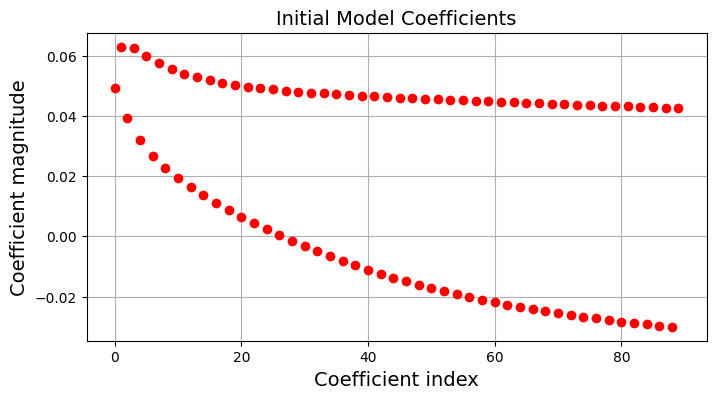

In [457]:
# Plot the coefficients of the initial model
plt.figure(figsize=(8, 4))
plt.plot(initial_model.coef_, "ro")
plt.xlabel("Coefficient index")
plt.ylabel("Coefficient magnitude")
plt.title("Initial Model Coefficients")
plt.grid()
plt.show()

---

# Logistic Regression

Logistic Regression is a classification algorithm used to predict discrete outcomes (typically binary: yes/no, true/false, 0/1). Despite its name containing "regression," it is actually used for **classification** tasks.

## Binary Classification
Logistic Regression estimates the probability that an instance belongs to a particular class. For binary classification:
- Output is a probability between 0 and 1
- A threshold (typically 0.5) is used to classify instances into one of two classes

## The Logistic (Sigmoid) Function
The core of Logistic Regression is the **sigmoid function**:

$$\sigma(t) = \frac{1}{1 + e^{-t}}$$

This function:
- Maps any real number to the range (0, 1)
- Produces S-shaped curve
- Outputs probabilities suitable for classification

## How It Works
1. Computes a weighted sum of input features: **t = θ₀ + θ₁x₁ + θ₂x₂ + ... + θₙxₙ**
2. Applies the sigmoid function: **p = σ(t)**
3. Predicts class 1 if p ≥ 0.5, otherwise class 0

## Cost Function
Logistic Regression uses **log loss** (binary cross-entropy) instead of Mean Squared Error:
$$J(θ) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(p^{(i)}) + (1 - y^{(i)}) \log(1 - p^{(i)}) \right]$$

Where:
- **m**: Number of training instances
- **y^{(i)}**: True label (0 or 1)
- **p^{(i)}**: Predicted probability for class 1
- Penalizes wrong predictions more heavily
- Convex function suitable for gradient descent optimization

## Applications
- Email spam detection (spam/not spam)
- Medical diagnosis (disease/no disease)
- Customer churn prediction (will leave/will stay)
- Credit risk assessment (default/no default)

Logistic Regression is simple, fast, interpretable, and often serves as a baseline for more complex classification algorithms.

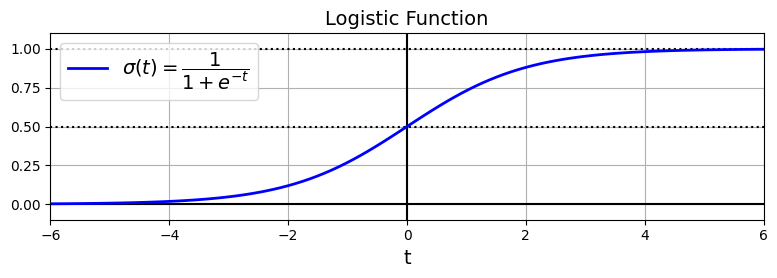

In [458]:
# extra code – generates and saves Figure 4–21

lim = 6
t = np.linspace(-lim, lim, 100)
sig = 1 / (1 + np.exp(-t))

plt.figure(figsize=(8, 3))
plt.plot([-lim, lim], [0, 0], "k-")
plt.plot([-lim, lim], [0.5, 0.5], "k:")
plt.plot([-lim, lim], [1, 1], "k:")
plt.plot([0, 0], [-0.1, 1.1], "k-")
plt.plot(t, sig, "b-", linewidth=2, label=r"$\sigma(t) = \dfrac{1}{1 + e^{-t}}$")
plt.xlabel("t")
plt.legend(loc="upper left")
plt.axis([-lim, lim, -0.1, 1.1])
plt.gca().set_yticks([0, 0.25, 0.5, 0.75, 1])
plt.grid()
plt.title("Logistic Function")
save_fig("logistic_function_plot")
plt.show()

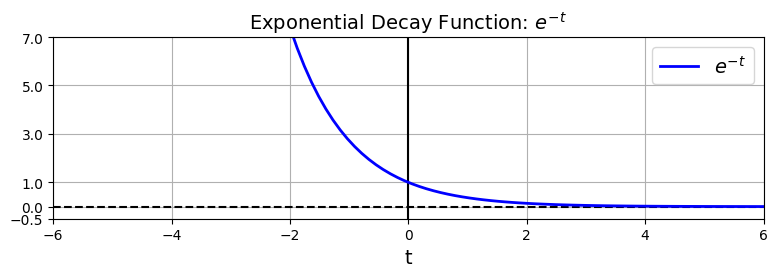

In [459]:
# Plot exp(-t) function
plt.figure(figsize=(8, 3))
plt.plot([-lim, lim], [0, 0], "k--")
plt.plot([0, 0], [-0.5, 7], "k-")
plt.plot(t, np.exp(-t), "b-", linewidth=2, label=r"$e^{-t}$")
plt.xlabel("t")
plt.legend(loc="upper right")
plt.axis([-lim, lim, -0.5, 7])
plt.grid()
plt.title(r"Exponential Decay Function: $e^{-t}$")
plt.gca().set_yticks([-0.5, 0, 1, 3, 5, 7])
save_fig("exp_neg_t_plot")
plt.show()

In [460]:
print(f'Value of exp: {np.exp(1)}')

Value of exp: 2.718281828459045


---
## Decision Boundaries
In Logistic Regression, the decision boundary is the *threshold at which the predicted probability of belonging to a certain class changes from one class to another*. For binary classification, this boundary is typically set at a probability of 0.5.

In [461]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [462]:
print(f'Type of iris: {type(iris)}')
print(f'Keys in iris.data: {iris.data.columns.tolist()}')
print(f'Type of iris.data.columns: {type(iris.data.columns)}')

Type of iris: <class 'sklearn.utils._bunch.Bunch'>
Keys in iris.data: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Type of iris.data.columns: <class 'pandas.core.indexes.base.Index'>


In [463]:
print(iris.data.shape)

(150, 4)


### Loading the Iris Dataset

This cell loads the famous **Iris dataset** using Scikit-Learn's `load_iris()` function with the `as_frame=True` parameter.

#### What is the Iris Dataset?

The Iris dataset is a classic dataset in machine learning, containing measurements of 150 iris flowers from three different species:
- **Iris setosa**
- **Iris versicolor**
- **Iris virginica**

#### Features in the Dataset

Each flower has four measurements (features):
1. **Sepal length** (cm)
2. **Sepal width** (cm)
3. **Petal length** (cm)
4. **Petal width** (cm)

#### The `as_frame=True` Parameter

By setting `as_frame=True`, the dataset is returned as a **Bunch object** containing *pandas DataFrames* instead of NumPy arrays. This makes it easier to work with the data in a structured format.

#### Dataset Structure

The `list(iris)` command shows the keys available in the Bunch object:
- **`data`**: DataFrame with the four features
- **`target`**: Series with the class labels (0, 1, 2 for the three species)
- **`frame`**: Complete DataFrame with both features and target
- **`target_names`**: Array of species names
- **`DESCR`**: Description of the dataset
- **`feature_names`**: List of feature column names
- **`filename`**: Path to the dataset file

This dataset is commonly used for classification tasks and will be used here to demonstrate Logistic Regression for binary classification (distinguishing *Iris virginica* from other species).

In [464]:
print(iris.DESCR)  # extra code – it's a bit too long

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive attributes and the class
    :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm
        - class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Virginica
                
    :Summary Statistics:

    ============== ==== ==== ======= ===== ====================
                    Min  Max   Mean    SD   Class Correlation
    ============== ==== ==== ======= ===== ====================
    sepal length:   4.3  7.9   5.84   0.83    0.7826
    sepal width:    2.0  4.4   3.05   0.43   -0.4194
    petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
    petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
    ============== ==== ==== ======= ===== ===========

In [465]:
iris.data.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [466]:
type(iris.data)

pandas.core.frame.DataFrame

In [467]:
iris.data.keys()

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='object')

In [468]:
iris.target.head(5)  # note that the instances are not shuffled

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int32

In [469]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [470]:
print(f'Shape of iris.target: {iris.target.shape}')
print(f'Shape of iris.target_names: {iris.target_names.shape}')

Shape of iris.target: (150,)
Shape of iris.target_names: (3,)


### Preparing the Data for Binary Classification

This cell prepares the Iris dataset for a binary classification task: predicting whether a flower is *Iris virginica* or not.

**Feature Selection:**
- `X = iris.data[["petal width (cm)"]].values`: We select only the "petal width (cm)" feature to use as our predictor variable. Using `.values` converts the pandas DataFrame column into a NumPy array, which is the standard input format for Scikit-Learn models.

**Target Variable Creation:**
- `y = (iris.target == 2).astype(int)`: This creates the binary target variable `y`.
    - `iris.target == 2` creates a boolean Series where `True` corresponds to *Iris virginica* (since its label is 2) and `False` corresponds to the other two species.
    - `.astype(int)` converts these boolean values into integers: `True` becomes `1` and `False` becomes `0`.

Now, we have:
- **`X`**: A feature matrix with a single feature (petal width).
- **`y`**: A target vector with binary labels (1 for *Iris virginica*, 0 for others).

This setup allows us to train a logistic regression model to distinguish one class from the rest based on a single measurement.

In [471]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = iris.data[["petal width (cm)"]].values # feature matrix with one feature; convert to numpy array
y = iris.target_names[iris.target] == 'virginica' # target vector: True if virginica, else False
print(f'Shape of X: {X.shape}, Shape of y: {y.shape}')
print(f'Type of X: {type(X)}, Type of y: {type(y)}')
print(f'First 5 entries of y: {y[:5]}')

# split the dataset into a training set and a test set
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# train the logistic regression model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

Shape of X: (150, 1), Shape of y: (150,)
Type of X: <class 'numpy.ndarray'>, Type of y: <class 'numpy.ndarray'>
First 5 entries of y: [False False False False False]


LogisticRegression(random_state=42)

Shape of y_proba: (1000, 2)
First 5 rows of y_proba:
[[0.99822633 0.00177367]
 [0.99820582 0.00179418]
 [0.99818506 0.00181494]
 [0.99816407 0.00183593]
 [0.99814284 0.00185716]]


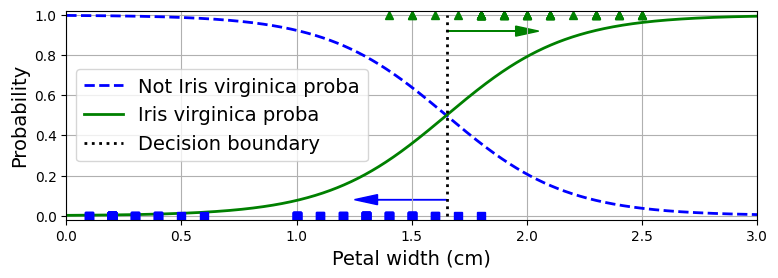

In [472]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

X_new = np.linspace(0, 3, 1000).reshape(-1, 1)  # reshape to get a column vector
y_proba = log_reg.predict_proba(X_new)
print(f'Shape of y_proba: {y_proba.shape}')  # should be (1000, 2) for two classes
print(f'First 5 rows of y_proba:\n{y_proba[:5]}')

# find the decision boundary where the probability of class 1 is 0.5
decision_boundary = X_new[y_proba[:, 1] >= 0.5][0, 0]

plt.figure(figsize=(8, 3))  # extra code – not needed, just formatting
plt.plot(X_new, y_proba[:, 0], "b--", linewidth=2,
         label="Not Iris virginica proba") # probability of class 0
plt.plot(X_new, y_proba[:, 1], "g-", linewidth=2, label="Iris virginica proba") # probability of class 1
plt.plot([decision_boundary, decision_boundary], [0, 1], "k:", linewidth=2,
         label="Decision boundary")

# extra code – this section beautifies and saves Figure 4–23
plt.arrow(x=decision_boundary, y=0.08, dx=-0.3, dy=0,
          head_width=0.05, head_length=0.1, fc="b", ec="b")
plt.arrow(x=decision_boundary, y=0.92, dx=0.3, dy=0,
          head_width=0.05, head_length=0.1, fc="g", ec="g")
plt.plot(X_train[y_train == 0], y_train[y_train == 0], "bs") # class 0 training instances marked as blue squares
plt.plot(X_train[y_train == 1], y_train[y_train == 1], "g^") # class 1 training instances marked as green triangles
plt.xlabel("Petal width (cm)")
plt.ylabel("Probability")
plt.legend(loc="center left")
plt.axis([0, 3, -0.02, 1.02])
plt.grid()
save_fig("logistic_regression_plot")

plt.show()

In [473]:
print(X_new.shape)
print(y_proba.shape)

(1000, 1)
(1000, 2)


In [474]:
X_new[:5]  # show first 5 rows

array([[0.        ],
       [0.003003  ],
       [0.00600601],
       [0.00900901],
       [0.01201201]])

In [475]:
X_new[0], X_new[-1]

(array([0.]), array([3.]))

In [476]:
y_proba[:,1] >= 0.5

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

**Boolean Indexing Explanation:**
- `y_proba[:, 1] >= 0.5` creates a boolean array where each entry is `True` if the predicted probability of being *Iris virginica* (class 1) is greater than or equal to 0.5, and `False` otherwise.
This boolean array is then converted to integers (1 for `True`, 0 for `False`) using `.astype(int)`, resulting in the final predicted class labels.

In [477]:
X_new[y_proba[:, 1] >= 0.5]

array([[1.65165165],
       [1.65465465],
       [1.65765766],
       [1.66066066],
       [1.66366366],
       [1.66666667],
       [1.66966967],
       [1.67267267],
       [1.67567568],
       [1.67867868],
       [1.68168168],
       [1.68468468],
       [1.68768769],
       [1.69069069],
       [1.69369369],
       [1.6966967 ],
       [1.6996997 ],
       [1.7027027 ],
       [1.70570571],
       [1.70870871],
       [1.71171171],
       [1.71471471],
       [1.71771772],
       [1.72072072],
       [1.72372372],
       [1.72672673],
       [1.72972973],
       [1.73273273],
       [1.73573574],
       [1.73873874],
       [1.74174174],
       [1.74474474],
       [1.74774775],
       [1.75075075],
       [1.75375375],
       [1.75675676],
       [1.75975976],
       [1.76276276],
       [1.76576577],
       [1.76876877],
       [1.77177177],
       [1.77477477],
       [1.77777778],
       [1.78078078],
       [1.78378378],
       [1.78678679],
       [1.78978979],
       [1.792

Next, this boolean mask is used to index the `X_new` array: `X_new[y_proba[:, 1] >= 0.5]`. This is a powerful NumPy feature called **boolean indexing**. It filters `X_new` and returns a new array containing only the elements from `X_new` where the corresponding value in the mask is `True`. In other words, it gives you all the petal width values for which the model predicts *Iris virginica*.

In [480]:
print(f"{X_new[y_proba[:, 1] >= 0.5].shape}")
X_new[y_proba[:, 1] >= 0.5][0, 0]

(450, 1)


1.6516516516516517

Finally, `[0, 0]` indexing is applied. Since `X_new` is a sorted array of petal widths, the first element of the filtered array (`[0]`) will be the smallest petal width that resulted in a probability of 50% or more. This value is your **decision boundary**. The second `[0]` is used to extract the scalar value from the resulting NumPy array, which would otherwise have a shape like `(1, 1)`.

In [481]:
X_new[y_proba[:, 1] >= 0.5][0]

array([1.65165165])

In [482]:
y_proba[:5]

array([[0.99822633, 0.00177367],
       [0.99820582, 0.00179418],
       [0.99818506, 0.00181494],
       [0.99816407, 0.00183593],
       [0.99814284, 0.00185716]])

### Logistic Regression Probability Visualization

This code demonstrates how Logistic Regression estimates probabilities and establishes decision boundaries for binary classification using the Iris dataset.

#### Data Preparation and Model Training

**Feature and Target Setup:**
- `X = iris.data[["petal width (cm)"]].values`: Uses petal width as the single predictor variable
    - the double brackets `[[...]]` ensure `X` is a 2D array (required by Scikit-Learn)
    - `.values` converts the DataFrame column to a NumPy array
- `y = iris.target_names[iris.target] == 'virginica'`: Creates binary target (True for *Iris virginica*, False for others)
    - `iris.target_names[iris.target]` extracts the species names for the target labels
- **Train-test split**: Divides data into training and testing sets with `random_state=42` for reproducibility

**Model Training:**
- `LogisticRegression()` is trained on the training data to learn the relationship between petal width and the probability of being *Iris virginica*

#### Probability Estimation and Decision Boundary

**Probability Calculation:**
- `X_new = np.linspace(0, 3, 1000).reshape(-1, 1)`: Creates 1000 evenly spaced petal width values from 0 to 3 cm
- `y_proba = log_reg.predict_proba(X_new)`: Computes predicted probabilities for each petal width value
    - `y_proba[:, 0]`: Probability of NOT being *Iris virginica*
    - `y_proba[:, 1]`: Probability of being *Iris virginica*

**Decision Boundary:**
- `decision_boundary = X_new[y_proba[:, 1] >= 0.5][0, 0]`: Finds the petal width where the probability of being *Iris virginica* first reaches 0.5

#### Visualization Components

**Probability Curves:**
- **Blue dashed line**: Shows how probability of NOT being *Iris virginica* changes with petal width
- **Green solid line**: Shows how probability of being *Iris virginica* increases with petal width
- **Black dotted line**: Marks the decision boundary (probability = 0.5)

**Data Points:**
- **Blue squares**: Training instances that are NOT *Iris virginica*
- **Green triangles**: Training instances that ARE *Iris virginica*

**Arrows:**
- Visual indicators showing the classification regions separated by the decision boundary

#### Key Insights

The visualization clearly shows:
- **Low petal width** (< ~1.6 cm): High probability of NOT being *Iris virginica*
- **High petal width** (> ~1.6 cm): High probability of being *Iris virginica*
- **Smooth transition**: The sigmoid function creates a gradual probability change rather than an abrupt jump
- **Decision boundary**: Around 1.6 cm petal width, where the model switches its prediction

This figure (saved as `logistic_regression_plot`) illustrates how Logistic Regression transforms a linear decision boundary in the feature space into probability estimates that smoothly transition between 0 and 1.

In [483]:
decision_boundary

1.6516516516516517

In [484]:
log_reg.predict([[1.7], [1.5]])

array([ True, False])

### Logistic Regression with Two Features: Probability Contours and Decision Boundary

In [485]:
list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [486]:
print(iris.data.head(5))
print(f"Type of iris.data: {type(iris.data)}")

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
Type of iris.data: <class 'pandas.core.frame.DataFrame'>


Type of X: <class 'numpy.ndarray'>, Shape of X: (150, 2)
Type of y: <class 'numpy.ndarray'>, Shape of y: (150,)
Shape of x0: (200, 500), Shape of x1: (200, 500)
Shape of X_new: (100000, 2)
Shape of zz: (200, 500)
Shape of y_train: (112,)


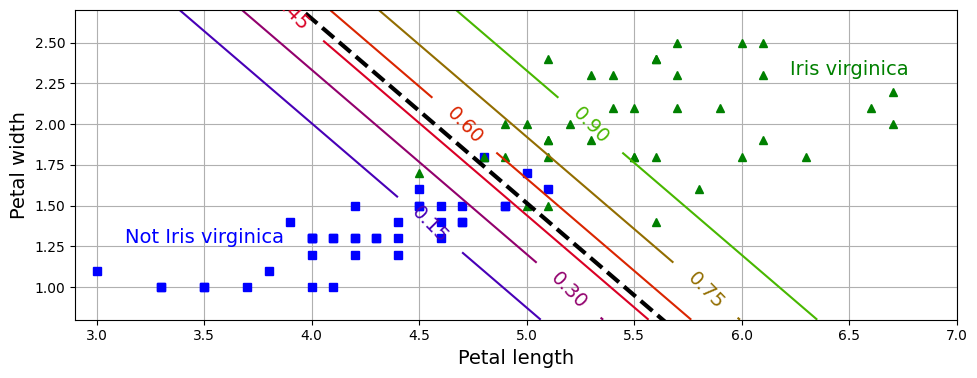

In [487]:
# extra code – this cell generates and saves Figure 4–24

X = iris.data[["petal length (cm)", "petal width (cm)"]].values # feature matrix with two features; pandas DataFrame column selection followed by conversion to NumPy array
# Using .to_numpy() (modern pandas)
# X = iris.data[["petal length (cm)", "petal width (cm)"]].to_numpy()
y = iris.target_names[iris.target] == 'virginica'
print(f'Type of X: {type(X)}, Shape of X: {X.shape}')
print(f'Type of y: {type(y)}, Shape of y: {y.shape}')
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

log_reg = LogisticRegression(C=2, random_state=42) # C is the inverse of regularization strength
log_reg.fit(X_train, y_train)

# for the contour plot
x0, x1 = np.meshgrid(np.linspace(2.9, 7, 500).reshape(-1, 1),
                     np.linspace(0.8, 2.7, 200).reshape(-1, 1))
print(f'Shape of x0: {x0.shape}, Shape of x1: {x1.shape}')
X_new = np.c_[x0.ravel(), x1.ravel()]  # one instance per point on the figure
print(f'Shape of X_new: {X_new.shape}')
y_proba = log_reg.predict_proba(X_new)
zz = y_proba[:, 1].reshape(x0.shape)
print(f'Shape of zz: {zz.shape}')

# for the decision boundary
left_right = np.array([2.9, 7]) # x values for the decision boundary line
boundary = -((log_reg.coef_[0, 0] * left_right + log_reg.intercept_[0])
             / log_reg.coef_[0, 1]) # corresponding y values

print(f'Shape of y_train: {y_train.shape}')

plt.figure(figsize=(10, 4))
plt.plot(X_train[y_train == 0, 0], X_train[y_train == 0, 1], "bs") # class 0 training instances
plt.plot(X_train[y_train == 1, 0], X_train[y_train == 1, 1], "g^") # class 1 training instances
contour = plt.contour(x0, x1, zz, cmap=plt.cm.brg)
plt.clabel(contour, inline=1)
plt.plot(left_right, boundary, "k--", linewidth=3)
plt.text(3.5, 1.27, "Not Iris virginica", color="b", ha="center")
plt.text(6.5, 2.3, "Iris virginica", color="g", ha="center")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.axis([2.9, 7, 0.8, 2.7])
plt.grid()
save_fig("logistic_regression_contour_plot")
plt.show()

This cell trains a binary Logistic Regression classifier to distinguish Iris virginica using two features and visualizes both the probability surface and the linear decision boundary.

#### 1) Data setup and training
- Features: petal length and petal width
    - `X = iris.data[["petal length (cm)", "petal width (cm)"]].values`
    - it uses pandas DataFrame column selection with double brackets to ensure a 2D array
    - `.values` converts to NumPy array
        - alternatively, could use `iris.data[["petal length (cm)", "petal width (cm)"]].to_numpy()`
- Target: boolean (True if virginica)
    - `y = (iris.target == 2).astype(int)`
- Split into train/test for reproducibility
- Model: LogisticRegression(C=2)
    - C is the inverse of regularization strength (higher C → weaker regularization)
    - Fit on training data to learn coefficients and intercept

#### 2) Probability grid for contour plot
- Build a dense grid over the 2D feature space using `np.meshgrid`
    - `x0, x1 = np.meshgrid(np.linspace(2.9, 7, 500).reshape(-1, 1),
                     np.linspace(0.8, 2.7, 200).reshape(-1, 1))`
    - `np.linspace(2.9, 7, 500)` and `np.linspace(0.8, 2.7, 200)` create 500 petal-length and 200 petal-width coordinates spanning the plot ranges.
    - `.reshape(-1, 1)` converts each 1D vector to a column vector (not strictly required) before gridding.
    - `np.meshgrid(...)` expands these into 2D coordinate grids: with default `'xy'` indexing, `x0` holds petal-length coordinates (the 500-length vector repeated across rows) and `x1` holds petal-width coordinates (the 200-length vector repeated down columns).
    - Both `x0` and `x1` have shape `(200, 500)` = (Ny, Nx), giving one (length, width) pair per grid cell.
- Stack grid into `X_new` and compute class probabilities with `predict_proba`
    - Flatten grid arrays and stack into `X_new` for prediction
        - `X_new = np.c_[x0.ravel(), x1.ravel()]`
    - `y_proba = log_reg.predict_proba(X_new)` gives probabilities for each grid point
- Extract probabilities for class "virginica": `zz = y_proba[:, 1].reshape(x0.shape)`
    - where `y_proba` shape is `(200*500, 2)` (one row per grid point, two columns for class probabilities)
    - `y_proba[:, 1]` gets P(virginica) for each grid point, then reshaped back to `(200, 500)` to match the grid for contour plotting
    - Reshape probabilities into `zz` to match the grid for contour plotting
        - `zz[i, j]` is P(virginica | feature point at grid cell i, j)

#### 3) Decision boundary calculation
- For logistic regression, the 0.5-probability boundary is linear:
    - Given weights w = [w_len, w_wid] and bias b:
        - boundary: petal_width = -(w_len * petal_length + b) / w_wid
- `left_right` sets the x-range of the line for plotting

#### 4) Visualization
- Blue squares: Non-virginica training points
- Green triangles: Virginica training points
- Contours: Probability levels of class “virginica” across the grid
- Dashed black line: Decision boundary (P=0.5)
- Axes limits and labels tuned to Iris feature ranges
- Figure saved via `save_fig("logistic_regression_contour_plot")`

#### How to read the plot
- Areas with higher contour values (toward green) indicate higher P(virginica)
- Points above the dashed line are predicted as virginica; below as non-virginica
- The spacing of contours reflects model confidence (denser = steeper probability change)

In [488]:
x0

array([[2.9       , 2.90821643, 2.91643287, ..., 6.98356713, 6.99178357,
        7.        ],
       [2.9       , 2.90821643, 2.91643287, ..., 6.98356713, 6.99178357,
        7.        ],
       [2.9       , 2.90821643, 2.91643287, ..., 6.98356713, 6.99178357,
        7.        ],
       ...,
       [2.9       , 2.90821643, 2.91643287, ..., 6.98356713, 6.99178357,
        7.        ],
       [2.9       , 2.90821643, 2.91643287, ..., 6.98356713, 6.99178357,
        7.        ],
       [2.9       , 2.90821643, 2.91643287, ..., 6.98356713, 6.99178357,
        7.        ]])

In [489]:
x0.ravel()

array([2.9       , 2.90821643, 2.91643287, ..., 6.98356713, 6.99178357,
       7.        ])

#### Understanding `ravel()` in NumPy

The `ravel()` method flattens a multi-dimensional NumPy array into a 1D array. In the code above, it's used to convert the 2D grid arrays into column vectors for processing.

##### Example from the Code

```python
x0, x1 = np.meshgrid(np.linspace(2.9, 7, 500).reshape(-1, 1),
                     np.linspace(0.8, 2.7, 200).reshape(-1, 1))
# x0 and x1 are 2D arrays with shape (200, 500)

X_new = np.c_[x0.ravel(), x1.ravel()]
# After ravel(), both become 1D arrays with shape (100000,)
# np.c_ then stacks them into shape (100000, 2)
```

##### Why Use `ravel()` Here?

**Purpose:** Transform the 2D coordinate grids into a list of individual (petal_length, petal_width) points that can be fed to the classifier.

**Process:**
1. **Grid creation:** `x0` and `x1` are 2D grids (200×500) representing all combinations of petal length and width
2. **Flattening:** `ravel()` converts each 2D grid into a 1D vector of 100,000 points
3. **Stacking:** `np.c_[x0.ravel(), x1.ravel()]` creates a (100,000, 2) array where each row is a (length, width) pair
4. **Prediction:** The model predicts class probabilities for all 100,000 points
5. **Reshaping back:** `zz = y_proba[:, 1].reshape(x0.shape)` converts predictions back to 2D for contour plotting

##### Visual Example

```python
# Before ravel()
x0 = [[2.9, 2.91, 2.92],
      [2.9, 2.91, 2.92]]  # shape: (2, 3)

# After ravel()
x0.ravel() = [2.9, 2.91, 2.92, 2.9, 2.91, 2.92]  # shape: (6,)
```

##### Key Difference: `ravel()` vs `flatten()`

- **`ravel()`**: Returns a *view* when possible (memory efficient, changes affect original)
- **`flatten()`**: Always returns a *copy* (safe but uses more memory)

In this code, `ravel()` is preferred because we only need a temporary 1D view for prediction, not a permanent copy.

In [490]:
x1

array([[0.8       , 0.8       , 0.8       , ..., 0.8       , 0.8       ,
        0.8       ],
       [0.80954774, 0.80954774, 0.80954774, ..., 0.80954774, 0.80954774,
        0.80954774],
       [0.81909548, 0.81909548, 0.81909548, ..., 0.81909548, 0.81909548,
        0.81909548],
       ...,
       [2.68090452, 2.68090452, 2.68090452, ..., 2.68090452, 2.68090452,
        2.68090452],
       [2.69045226, 2.69045226, 2.69045226, ..., 2.69045226, 2.69045226,
        2.69045226],
       [2.7       , 2.7       , 2.7       , ..., 2.7       , 2.7       ,
        2.7       ]])

In [491]:
x1.ravel()

array([0.8, 0.8, 0.8, ..., 2.7, 2.7, 2.7])

#### Understanding Decision Boundary Calculation

This code calculates and plots the **decision boundary** of a logistic regression model, which is the line that separates different classes in your feature space.

##### The Mathematical Foundation

A logistic regression decision boundary occurs where the model's probability prediction equals 0.5 (or where the log-odds equals 0). Mathematically, this happens when:

$$w_0 \cdot x_0 + w_1 \cdot x_1 + b = 0$$

Where $w_0$ and $w_1$ are the coefficients (weights), $x_0$ and $x_1$ are your features, and $b$ is the intercept (bias term).

##### Breaking Down the Code

**Line 1: Defining the x-axis range**
```python
left_right = np.array([2.9, 7])
```
This creates two x-coordinates (2.9 and 7) that define the left and right boundaries of where you want to draw the decision line. These values likely correspond to the minimum and maximum of your "petal length" feature in the iris dataset.

**Line 2-3: Solving for the y-coordinates**
```python
boundary = -((log_reg.coef_[0, 0] * left_right + log_reg.intercept_[0])
             / log_reg.coef_[0, 1])
```
This solves for the y-coordinates (petal width values) using the rearranged equation:

$$x_1 = -\frac{w_0 \cdot x_0 + b}{w_1}$$

Breaking it down further:
- `log_reg.coef_[0, 0]` is $w_0$ (coefficient for petal length)
- `log_reg.coef_[0, 1]` is $w_1$ (coefficient for petal width)
- `log_reg.intercept_[0]` is $b$ (the bias/intercept term)
- `left_right` represents $x_0$ values (petal length)

##### The Key Insight

The negative sign at the beginning and the division rearranges the linear equation to isolate the y-variable (petal width). Think of it like solving $ax + by + c = 0$ for $y$: you get $y = -(ax + c) / b$.

##### Visualization Purpose

After computing `boundary`, you would typically plot it using:
```python
plt.plot(left_right, boundary, "k--", linewidth=3)
```
This creates a line that visually separates the regions where the model predicts different classes. Points above the line belong to one class, points below belong to another.

##### A Potential Gotcha

Notice the indexing `[0, 0]` and `[0, 1]` - these assume you're working with a **binary classification** problem. If you have multi-class classification with one-vs-rest, you'd need to be careful about which classifier's coefficients you're accessing.

In [492]:
print(boundary)

[ 3.89170127 -0.74857557]


#### Plotting Training Data by Class

These two lines visualize the training data points from a binary classification problem, with each class displayed using different colors and markers to make them easily distinguishable.

##### Understanding the Array Indexing Pattern

Both lines follow the same indexing pattern: `X_train[y_train == class_value, feature_index]`. This is a powerful NumPy boolean indexing technique that works in two steps:

1. **Boolean mask creation**: `y_train == 0` creates a boolean array where `True` indicates samples belonging to class 0, and `False` indicates all others
2. **Row and column selection**: The syntax `[boolean_mask, column_index]` simultaneously filters rows (samples) and selects a specific feature column

Think of it like using a filter and then picking a specific column from your filtered results—all in one compact expression.

##### Breaking Down Each Plot Call

**First line - Class 0 (Iris-Setosa):**
```python
plt.plot(X_train[y_train == 0, 0], X_train[y_train == 0, 1], "bs")
```
- `X_train[y_train == 0, 0]`: x-coordinates (petal length for class 0 samples)
- `X_train[y_train == 0, 1]`: y-coordinates (petal width for class 0 samples)
- `"bs"`: format string meaning **b**lue **s**quare markers

**Second line - Class 1 (not Iris-Setosa):**
```python
plt.plot(X_train[y_train == 1, 0], X_train[y_train == 1, 1], "g^")
```
- `X_train[y_train == 1, 0]`: x-coordinates (petal length for class 1 samples)
- `X_train[y_train == 1, 1]`: y-coordinates (petal width for class 1 samples)
- `"g^"`: format string meaning **g**reen **^**triangle (pointing up) markers

##### The Format String Shorthand

The format strings `"bs"` and `"g^"` are matplotlib shortcuts that combine color and marker style. The pattern is `[color][marker]`:
- Color codes: `b`=blue, `g`=green, `r`=red, `k`=black, etc.
- Marker codes: `s`=square, `^`=triangle up, `o`=circle, `*`=star, etc.

This is more concise than writing `color='blue', marker='s'` as separate keyword arguments.

##### Why This Visualization Matters

This scatter plot serves several purposes:
1. **Visual verification**: You can see if the classes are linearly separable
2. **Context for the decision boundary**: When combined with the decision boundary line from your earlier code, you can see how well the logistic regression model separates the two classes
3. **Data distribution insight**: You can spot clusters, outliers, or overlapping regions

##### A Common Gotcha

Notice that this code assumes `X_train` has **exactly two features** (indexed as 0 and 1). If your dataset has more features, you're only visualizing two dimensions. This is typical in machine learning tutorials where higher-dimensional data is projected onto 2D for visualization purposes. In your iris dataset case, you're specifically looking at petal length (feature 0) versus petal width (feature 1).

#### Understanding Contour Plot and Labels

These two lines create a **contour plot** (lines of constant probability) for your logistic regression decision boundary and then add **numeric labels** to those contour lines.

##### What Each Line Does

**First line - Creating the contour plot:**
```python
contour = plt.contour(x0, x1, zz, cmap=plt.cm.brg)
```
- `x0`: The x-axis grid values (petal length range)
- `x1`: The y-axis grid values (petal width range)  
- `zz`: The predicted probabilities at each grid point (computed earlier via `predict_proba`)
- `cmap=plt.cm.brg`: Sets the colormap to "blue-red-green" for different probability levels
- Returns a `QuadContourSet` object stored in `contour` for later labeling

**Second line - Labeling the contours:**
```python
plt.clabel(contour, inline=1)
```
- Takes the `contour` object from the previous line
- Adds numeric labels showing the probability value at each contour line
- `inline=1` (or `inline=True`) removes the background line where labels are placed, making them easier to read

##### How Contour Plots Work

Think of a contour plot like a topographic map where each line connects points of equal elevation. Here, instead of elevation, each line connects points with the **same predicted probability**. For example:
- A contour line labeled "0.5" shows where the model predicts exactly 50% probability (the decision boundary)
- Lines labeled "0.7" show where the model is 70% confident about class 1
- Lines labeled "0.3" show where the model is 30% confident about class 1 (or 70% confident about class 0)

##### Visualizing the Complete Picture

When combined with your training data scatter plots, you get a comprehensive visualization:
1. **Blue squares** and **green triangles** show actual training samples
2. **Contour lines** show the model's probability predictions across the entire space
3. **Numeric labels** on contours tell you the exact probability values

##### The Key Gotcha

The contour lines only show probability **gradients**—they don't directly show the decision boundary itself. However:
- The **0.5 probability contour** is your decision boundary (where the model switches from predicting class 0 to class 1)
- Contours above 0.5 indicate regions where class 1 is predicted
- Contours below 0.5 indicate regions where class 0 is predicted

##### About That Colormap Warning

The type checker is warning about `plt.cm.brg` because it's checking if "brg" exists as an attribute. In practice, matplotlib's colormap system works, but for better type safety, you could use:

````python
contour = plt.contour(x0, x1, zz, cmap='brg')  # Pass as string instead
````

This achieves the same result while avoiding the type checker warning. The `'brg'` colormap creates a nice visual gradient from blue (low probabilities) through red to green (high probabilities).

---

## Softmax Regression

**Softmax Regression** (also called **multinomial logistic regression**) generalizes logistic regression to multi-class classification problems where K ≥ 3.

### How It Works

**1. Scoring Each Class:**
For each class $k$, the model computes a score:

$$z_k = \boldsymbol{\theta}_k^T \mathbf{x}$$

Where $\boldsymbol{\theta}_k$ is the weight vector for class $k$ and $\mathbf{x}$ is the input feature vector.

**2. Softmax Function:**
These scores are converted to probabilities using the **softmax function**:

$$p_k = \frac{\exp(z_k)}{\sum_{j=1}^{K} \exp(z_j)}$$

This ensures:
- All probabilities are non-negative
- Probabilities sum to 1 across all classes with $\sum_{k=1}^{K} p_k = 1$

**3. Prediction:**
The model predicts the class with the highest probability:

$$\hat{y} = \underset{k}{\text{argmax}} \, p_k$$

It means the predicted class is the one with the maximum softmax probability.

### Training

**Cost Function:**
Softmax Regression is trained by minimizing the **multinomial cross-entropy** (negative log-likelihood):

$$J(\boldsymbol{\Theta}) = -\frac{1}{m} \sum_{i=1}^{m} \sum_{k=1}^{K} y_k^{(i)} \log(p_k^{(i)})$$

Where:
- $m$ is the number of training instances
- $K$ is the number of classes
- $y_k^{(i)}$ is 1 if instance $i$ belongs to class $k$, otherwise 0 (one-hot encoding)
- $p_k^{(i)}$ is the predicted probability that instance $i$ belongs to class $k$
- $\boldsymbol{\Theta}$ is the matrix of all class weight vectors

**Optimization:**
Typically optimized using gradient-based methods such as:
- **L-BFGS** (Limited-memory Broyden–Fletcher–Goldfarb–Shanno)
- **SGD** (Stochastic Gradient Descent)
- **SAGA** (Stochastic Average Gradient Augmented)

### Regularization

To control overfitting, regularization penalties can be added:
- **L2 (Ridge)**: Penalizes large weights, keeps all features
- **L1 (Lasso)**: Can set some weights to zero, performs feature selection
- **Elastic Net**: Combines L1 and L2 penalties

### Comparison to One-vs-Rest (OvR)

| **Aspect**              | **Softmax Regression**                     | **One-vs-Rest (OvR)**                      |
|-------------------------|--------------------------------------------|--------------------------------------------|
| **Training**            | Learns all classes jointly                 | Trains separate binary classifier per class |
| **Probabilities**       | Better calibrated, sum to 1                | Independent probabilities, may not sum to 1 |
| **Decision Boundaries** | Often smoother and more coherent           | Can be less smooth                          |
| **Use Case**            | When classes are mutually exclusive        | More flexible, works with any binary classifier |


In [493]:
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris["target"]
print(f'Shape of X: {X.shape}, Shape of y: {y.shape}')
print(f'First 5 instances of X:\n{X[:5, :]}')
print(f'First 5 instances of y:\n{y[:5].values}')

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

softmax_reg = LogisticRegression(C=30, random_state=42)
softmax_reg.fit(X_train, y_train)

Shape of X: (150, 2), Shape of y: (150,)
First 5 instances of X:
[[1.4 0.2]
 [1.4 0.2]
 [1.3 0.2]
 [1.5 0.2]
 [1.4 0.2]]
First 5 instances of y:
[0 0 0 0 0]


LogisticRegression(C=30, random_state=42)

### Softmax Regression for Multi-class Classification

This code demonstrates **Softmax Regression** (also known as multinomial logistic regression) for classifying all three Iris species simultaneously.

#### Dataset Preparation

**Feature Selection:**
- `X = iris.data[["petal length (cm)", "petal width (cm)"]].values`: Uses two features (petal length and width) instead of just one, providing more information for distinguishing between the three species
- `y = iris["target"]`: Uses the original 3-class target variable (0=setosa, 1=versicolor, 2=virginica) instead of the binary classification used earlier

**Train-Test Split:**
- Divides the data into training and testing sets with `random_state=42` for reproducible results

#### Model Configuration

**LogisticRegression for Multi-class:**
- `C=30`: High regularization parameter (inverse of regularization strength), allowing the model more flexibility to fit the training data
- `random_state=42`: Ensures reproducible results
- **Default behavior**: When `y` has more than 2 classes, Scikit-Learn's `LogisticRegression` automatically uses **multinomial** (Softmax) regression

#### Key Differences from Binary Classification

**Softmax Function:**
- Instead of sigmoid function, uses softmax to convert class scores into probabilities
- Ensures all class probabilities sum to 1
- Each class gets its own set of parameters (θ₀, θ₁, θ₂ for each class)

**Decision Boundaries:**
- Creates decision boundaries that separate three classes simultaneously
- More complex than binary classification, as it must distinguish between multiple classes at once

**Applications:**
- This approach is ideal when you need to classify instances into one of several mutually exclusive categories
- The model will output probability estimates for all three Iris species for each prediction

This setup demonstrates how Logistic Regression naturally extends from binary to multi-class classification problems using the softmax function.

In [494]:
softmax_reg.predict([[5, 2]])

array([2])

### Making Predictions with Softmax Regression

It demonstrates how to use the trained Softmax Regression model to make predictions on new data.

#### Prediction Input
- `[[5, 2]]`: A new flower sample with:
    - **Petal length**: 5.0 cm
    - **Petal width**: 2.0 cm

#### Model Output
The `predict()` method returns the **predicted class label** (0, 1, or 2) for the input sample:
- **0**: Iris setosa
- **1**: Iris versicolor  
- **2**: Iris virginica

#### How Softmax Regression Works
1. **Score Calculation**: Computes a score for each class using the learned parameters
2. **Softmax Function**: Converts scores into probabilities that sum to 1
3. **Prediction**: Selects the class with the highest probability (argmax)

#### Alternative Methods
You could also use:
- `softmax_reg.predict_proba([[5, 2]])`: Returns probability estimates for all three classes
- `softmax_reg.decision_function([[5, 2]])`: Returns the raw class scores before softmax transformation

This single prediction demonstrates how the trained model can classify new iris flowers based on their petal measurements, distinguishing between all three species simultaneously.

In [495]:
softmax_reg.predict_proba([[5, 2]]).round(2)

array([[0.  , 0.04, 0.96]])

### Understanding Softmax Regression Predictions

The code cell above demonstrates two key prediction methods from the trained Softmax Regression model:

#### 1. Class Prediction
```python
softmax_reg.predict([[5, 2]])
```
- **Input**: A flower with petal length = 5.0 cm and petal width = 2.0 cm
- **Output**: The predicted class label (0, 1, or 2)
- **Result**: The model returns the single most likely class based on which has the highest probability

#### 2. Probability Estimates
```python
softmax_reg.predict_proba([[5, 2]]).round(2)
```
- **Input**: The same flower measurements [5.0 cm, 2.0 cm]
- **Output**: Probability distribution across all three classes, rounded to 2 decimal places
- **Format**: `[P(setosa), P(versicolor), P(virginica)]`

#### Interpreting the Results

The probability array shows how confident the model is about each class:

**For example, if the output is `[0.02, 0.28, 0.70]`:**
- **2% probability** of being *Iris setosa* (class 0)
- **28% probability** of being *Iris versicolor* (class 1)
- **70% probability** of being *Iris virginica* (class 2)

**Key properties:**
- All probabilities are between 0 and 1
- The three probabilities sum to exactly 1.0
- The class with the highest probability matches the `predict()` output
- Higher probability values indicate greater model confidence

#### Why This Matters

**Probability estimates provide more information than just the predicted class:**
- **High confidence**: One probability is near 1.0, others near 0 (e.g., `[0.01, 0.02, 0.97]`)
- **Uncertainty**: Probabilities are more evenly distributed (e.g., `[0.20, 0.45, 0.35]`)
- **Decision-making**: You can set custom thresholds or handle uncertain cases differently

In this case, the measurements [5, 2] suggest a flower with moderate-to-large petals, which is most consistent with *Iris virginica* (the largest species), explaining why it likely receives the highest probability.

In [496]:
print(f'Max. of X[:, 0]: {X[:, 0].max()}')
print(f'Max. of X[:, 1]: {X[:, 1].max()}')

Max. of X[:, 0]: 6.9
Max. of X[:, 1]: 2.5


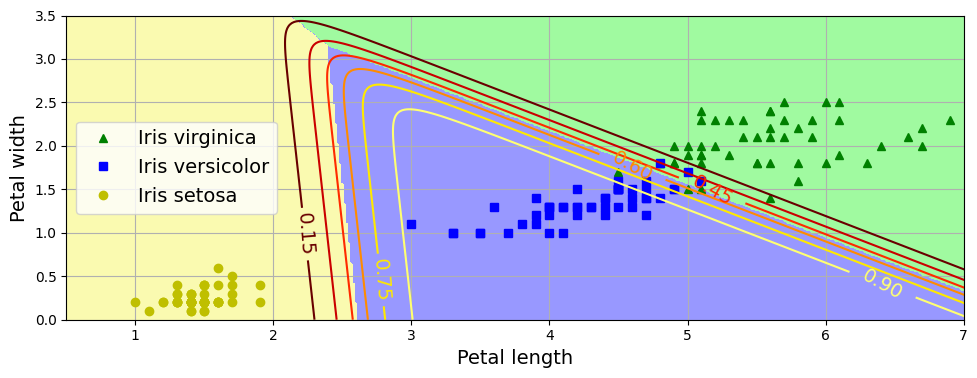

In [ ]:
# extra code – this cell generates and saves Figure 4–25

# Create a custom colormap with three colors for the three Iris classes
# ListedColormap creates a colormap from a list of colors
# Colors correspond to: setosa (yellow), versicolor (blue), virginica (green)
from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(["#fafab0", "#9898ff", "#a0faa0"])

x0, x1 = np.meshgrid(np.linspace(0, 8, 500).reshape(-1, 1),
                     np.linspace(0, 3.5, 200).reshape(-1, 1))
X_new = np.c_[x0.ravel(), x1.ravel()]

y_proba = softmax_reg.predict_proba(X_new)
y_predict = softmax_reg.predict(X_new)

zz1 = y_proba[:, 1].reshape(x0.shape)
zz = y_predict.reshape(x0.shape)

plt.figure(figsize=(10, 4))
plt.plot(X[y == 2, 0], X[y == 2, 1], "g^", label="Iris virginica")
plt.plot(X[y == 1, 0], X[y == 1, 1], "bs", label="Iris versicolor")
plt.plot(X[y == 0, 0], X[y == 0, 1], "yo", label="Iris setosa")

plt.contourf(x0, x1, zz, cmap=custom_cmap)
contour = plt.contour(x0, x1, zz1, cmap="hot")
plt.clabel(contour, inline=1)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="center left")
plt.axis((0.5, 7, 0, 3.5))
plt.grid()
save_fig("softmax_regression_contour_plot")
plt.show()

### Softmax Regression Decision Boundaries Visualization

This code creates a comprehensive visualization showing how Softmax Regression classifies the three Iris species using petal length and width measurements.

#### Visualization Setup

**Custom Color Map:**
- `ListedColormap(["#fafab0", "#9898ff", "#a0faa0"])`: Creates custom colors for the three classification regions
    - Light yellow for *Iris setosa*
    - Light blue for *Iris versicolor*  
    - Light green for *Iris virginica*

**Mesh Grid Creation:**
- `x0, x1 = np.meshgrid(...)`: Creates a fine grid of points covering the feature space
    - Petal length: 0 to 8 cm (500 points)
    - Petal width: 0 to 3.5 cm (200 points)
- `X_new = np.c_[x0.ravel(), x1.ravel()]`: Converts the 2D grid into a format suitable for model prediction

#### Model Predictions Across Feature Space

**Probability and Class Predictions:**
- `y_proba = softmax_reg.predict_proba(X_new)`: Computes class probabilities for every point in the grid
- `y_predict = softmax_reg.predict(X_new)`: Determines the predicted class for each grid point
- `zz1 = y_proba[:, 1].reshape(x0.shape)`: Extracts *Iris versicolor* probabilities for contour lines
- `zz = y_predict.reshape(x0.shape)`: Reshapes predictions back to grid format for visualization

#### Plot Components

**Data Points:**
- **Green triangles (^)**: *Iris virginica* training instances
- **Blue squares (s)**: *Iris versicolor* training instances  
- **Yellow circles (o)**: *Iris setosa* training instances

**Decision Regions:**
- `plt.contourf()`: Fills regions with colors showing where each class is predicted
- Creates distinct colored zones representing the model's classification decisions

**Probability Contours:**
- `plt.contour()` with `plt.clabel()`: Draws contour lines showing *Iris versicolor* probability levels
- "Hot" colormap creates gradient lines showing probability transitions
- Helps visualize how confident the model is in different regions

#### Key Insights

The visualization reveals:
- **Clear separation**: *Iris setosa* (yellow region) is easily distinguished with smaller petal measurements
- **Complex boundary**: The boundary between *Iris versicolor* and *Iris virginica* is more complex, reflecting the similarity between these species
- **Probability gradients**: Contour lines show smooth probability transitions rather than sharp boundaries
- **Model confidence**: Regions closer to training data clusters show higher confidence (darker contour lines)

This figure (saved as `softmax_regression_contour_plot`) effectively demonstrates how Softmax Regression creates multi-class decision boundaries and provides probabilistic classifications across the entire feature space.

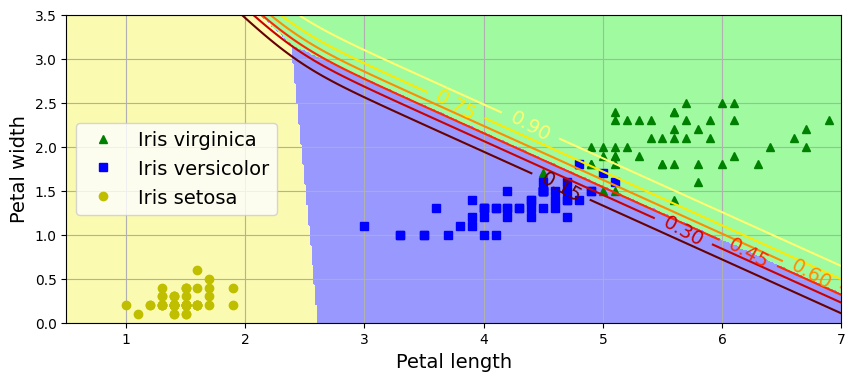

In [ ]:
# Extract probabilities for Iris virginica (class 2) instead of versicolor (class 1)
zz2 = y_proba[:, 2].reshape(x0.shape)
zz = y_predict.reshape(x0.shape)

plt.figure(figsize=(10, 4))
plt.plot(X[y == 2, 0], X[y == 2, 1], "g^", label="Iris virginica")
plt.plot(X[y == 1, 0], X[y == 1, 1], "bs", label="Iris versicolor")
plt.plot(X[y == 0, 0], X[y == 0, 1], "yo", label="Iris setosa")

plt.contourf(x0, x1, zz, cmap=custom_cmap)
contour = plt.contour(x0, x1, zz2, cmap="hot")
plt.clabel(contour, inline=1)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="center left")
plt.axis((0.5, 7, 0, 3.5))
plt.grid()
plt.show()

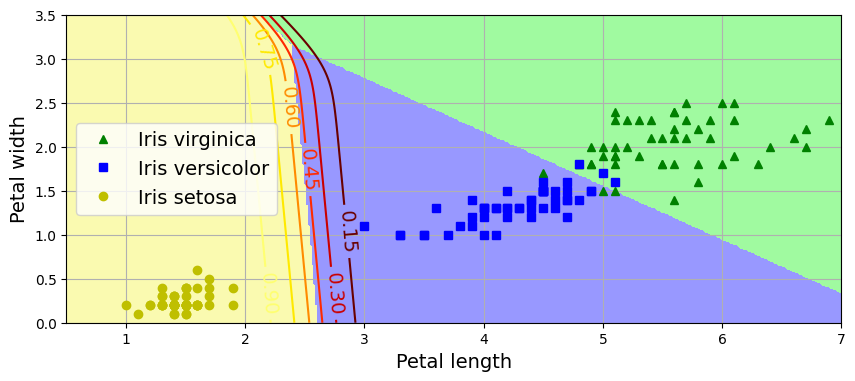

In [499]:
# Extract probabilities for Iris setosa (class 0) instead of virginica (class 2)
zz0 = y_proba[:, 0].reshape(x0.shape)
zz = y_predict.reshape(x0.shape)

plt.figure(figsize=(10, 4))
plt.plot(X[y == 2, 0], X[y == 2, 1], "g^", label="Iris virginica")
plt.plot(X[y == 1, 0], X[y == 1, 1], "bs", label="Iris versicolor")
plt.plot(X[y == 0, 0], X[y == 0, 1], "yo", label="Iris setosa")

plt.contourf(x0, x1, zz, cmap=custom_cmap)
contour = plt.contour(x0, x1, zz0, cmap="hot")
plt.clabel(contour, inline=1)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="center left")
plt.axis([0.5, 7, 0, 3.5])
plt.grid()
plt.show()

---

# Exercise solutions

## 1. to 11.

1. If you have a training set with millions of features you can use Stochastic Gradient Descent or Mini-batch Gradient Descent, and perhaps Batch Gradient Descent if the training set fits in memory. But you cannot use the Normal Equation or the SVD approach because the computational complexity grows quickly (more than quadratically) with the number of features.
2. If the features in your training set have very different scales, the cost function will have the shape of an elongated bowl, so the Gradient Descent algorithms will take a long time to converge. To solve this you should scale the data before training the model. Note that the Normal Equation or SVD approach will work just fine without scaling. Moreover, regularized models may converge to a suboptimal solution if the features are not scaled: since regularization penalizes large weights, features with smaller values will tend to be ignored compared to features with larger values.
3. Gradient Descent cannot get stuck in a local minimum when training a Logistic Regression model because the cost function is convex. _Convex_ means that if you draw a straight line between any two points on the curve, the line never crosses the curve.
4. If the optimization problem is convex (such as Linear Regression or Logistic Regression), and assuming the learning rate is not too high, then all Gradient Descent algorithms will approach the global optimum and end up producing fairly similar models. However, unless you gradually reduce the learning rate, Stochastic GD and Mini-batch GD will never truly converge; instead, they will keep jumping back and forth around the global optimum. This means that even if you let them run for a very long time, these Gradient Descent algorithms will produce slightly different models.
5. If the validation error consistently goes up after every epoch, then one possibility is that the learning rate is too high and the algorithm is diverging. If the training error also goes up, then this is clearly the problem and you should reduce the learning rate. However, if the training error is not going up, then your model is overfitting the training set and you should stop training.
6. Due to their random nature, neither Stochastic Gradient Descent nor Mini-batch Gradient Descent is guaranteed to make progress at every single training iteration. So if you immediately stop training when the validation error goes up, you may stop much too early, before the optimum is reached. A better option is to save the model at regular intervals; then, when it has not improved for a long time (meaning it will probably never beat the record), you can revert to the best saved model.
7. Stochastic Gradient Descent has the fastest training iteration since it considers only one training instance at a time, so it is generally the first to reach the vicinity of the global optimum (or Mini-batch GD with a very small mini-batch size). However, only Batch Gradient Descent will actually converge, given enough training time. As mentioned, Stochastic GD and Mini-batch GD will bounce around the optimum, unless you gradually reduce the learning rate.
8. If the validation error is much higher than the training error, this is likely because your model is overfitting the training set. One way to try to fix this is to reduce the polynomial degree: a model with fewer degrees of freedom is less likely to overfit. Another thing you can try is to regularize the model—for example, by adding an ℓ₂ penalty (Ridge) or an ℓ₁ penalty (Lasso) to the cost function. This will also reduce the degrees of freedom of the model. Lastly, you can try to increase the size of the training set.
9. If both the training error and the validation error are almost equal and fairly high, the model is likely underfitting the training set, which means it has a high bias. You should try reducing the regularization hyperparameter _α_.
10. Let's see:
  * A model with some regularization typically performs better than a model without any regularization, so you should generally prefer Ridge Regression over plain Linear Regression.
  * Lasso Regression uses an ℓ₁ penalty, which tends to push the weights down to exactly zero. This leads to sparse models, where all weights are zero except for the most important weights. This is a way to perform feature selection automatically, which is good if you suspect that only a few features actually matter. When you are not sure, you should prefer Ridge Regression.
  * Elastic Net is generally preferred over Lasso since Lasso may behave erratically in some cases (when several features are strongly correlated or when there are more features than training instances). However, it does add an extra hyperparameter to tune. If you want Lasso without the erratic behavior, you can just use Elastic Net with an `l1_ratio` close to 1.
11. If you want to classify pictures as outdoor/indoor and daytime/nighttime, since these are not exclusive classes (i.e., all four combinations are possible) you should train two Logistic Regression classifiers.

## 12. Batch Gradient Descent with early stopping for Softmax Regression
Exercise: _Implement Batch Gradient Descent with early stopping for Softmax Regression without using Scikit-Learn, only NumPy. Use it on a classification task such as the iris dataset._

Let's start by loading the data. We will just reuse the Iris dataset we loaded earlier.

In [500]:
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris["target"].values

We need to add the bias term for every instance ($x_0 = 1$). The easiest option to do this would be to use Scikit-Learn's `add_dummy_feature()` function, but the point of this exercise is to get a better understanding of the algorithms by implementing them manually. So here is one possible implementation:

In [501]:
X_with_bias = np.c_[np.ones(len(X)), X]

The easiest option to split the dataset into a training set, a validation set and a test set would be to use Scikit-Learn's `train_test_split()` function, but again, we want to do it manually:

In [502]:
test_ratio = 0.2
validation_ratio = 0.2
total_size = len(X_with_bias)

test_size = int(total_size * test_ratio)
validation_size = int(total_size * validation_ratio)
train_size = total_size - test_size - validation_size

np.random.seed(42)
rnd_indices = np.random.permutation(total_size)

X_train = X_with_bias[rnd_indices[:train_size]]
y_train = y[rnd_indices[:train_size]]
X_valid = X_with_bias[rnd_indices[train_size:-test_size]]
y_valid = y[rnd_indices[train_size:-test_size]]
X_test = X_with_bias[rnd_indices[-test_size:]]
y_test = y[rnd_indices[-test_size:]]

The targets are currently class indices (0, 1 or 2), but we need target class probabilities to train the Softmax Regression model. Each instance will have target class probabilities equal to 0.0 for all classes except for the target class which will have a probability of 1.0 (in other words, the vector of class probabilities for any given instance is a one-hot vector). Let's write a small function to convert the vector of class indices into a matrix containing a one-hot vector for each instance. To understand this code, you need to know that `np.diag(np.ones(n))` creates an n×n matrix full of 0s except for 1s on the main diagonal. Moreover, if `a` is a NumPy array, then `a[[1, 3, 2]]` returns an array with 3 rows equal to `a[1]`, `a[3]` and `a[2]` (this is [advanced NumPy indexing](https://numpy.org/doc/stable/user/basics.indexing.html#advanced-indexing)).

In [503]:
def to_one_hot(y):
    return np.diag(np.ones(y.max() + 1))[y]

Let's test this function on the first 10 instances:

In [504]:
y_train[:10]

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1])

In [505]:
to_one_hot(y_train[:10])

array([[0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.]])

Looks good, so let's create the target class probabilities matrix for the training set and the test set:

In [506]:
Y_train_one_hot = to_one_hot(y_train)
Y_valid_one_hot = to_one_hot(y_valid)
Y_test_one_hot = to_one_hot(y_test)

Now let's scale the inputs. We compute the mean and standard deviation of each feature on the training set (except for the bias feature), then we center and scale each feature in the training set, the validation set, and the test set:

In [507]:
mean = X_train[:, 1:].mean(axis=0)
std = X_train[:, 1:].std(axis=0)
X_train[:, 1:] = (X_train[:, 1:] - mean) / std
X_valid[:, 1:] = (X_valid[:, 1:] - mean) / std
X_test[:, 1:] = (X_test[:, 1:] - mean) / std

Now let's implement the Softmax function. Recall that it is defined by the following equation:

$\sigma\left(\mathbf{s}(\mathbf{x})\right)_k = \dfrac{\exp\left(s_k(\mathbf{x})\right)}{\sum\limits_{j=1}^{K}{\exp\left(s_j(\mathbf{x})\right)}}$

In [508]:
def softmax(logits):
    exps = np.exp(logits)
    exp_sums = exps.sum(axis=1, keepdims=True)
    return exps / exp_sums

We are almost ready to start training. Let's define the number of inputs and outputs:

In [509]:
n_inputs = X_train.shape[1]  # == 3 (2 features plus the bias term)
n_outputs = len(np.unique(y_train))  # == 3 (there are 3 iris classes)

Now here comes the hardest part: training! Theoretically, it's simple: it's just a matter of translating the math equations into Python code. But in practice, it can be quite tricky: in particular, it's easy to mix up the order of the terms, or the indices. You can even end up with code that looks like it's working but is actually not computing exactly the right thing. When unsure, you should write down the shape of each term in the equation and make sure the corresponding terms in your code match closely. It can also help to evaluate each term independently and print them out. The good news it that you won't have to do this everyday, since all this is well implemented by Scikit-Learn, but it will help you understand what's going on under the hood.

So the equations we will need are the cost function:

$J(\mathbf{\Theta}) =
- \dfrac{1}{m}\sum\limits_{i=1}^{m}\sum\limits_{k=1}^{K}{y_k^{(i)}\log\left(\hat{p}_k^{(i)}\right)}$

And the equation for the gradients:

$\nabla_{\mathbf{\theta}^{(k)}} \, J(\mathbf{\Theta}) = \dfrac{1}{m} \sum\limits_{i=1}^{m}{ \left ( \hat{p}^{(i)}_k - y_k^{(i)} \right ) \mathbf{x}^{(i)}}$

Note that $\log\left(\hat{p}_k^{(i)}\right)$ may not be computable if $\hat{p}_k^{(i)} = 0$. So we will add a tiny value $\epsilon$ to $\log\left(\hat{p}_k^{(i)}\right)$ to avoid getting `nan` values.

In [510]:
eta = 0.5
n_epochs = 5001
m = len(X_train)
epsilon = 1e-5

np.random.seed(42)
Theta = np.random.randn(n_inputs, n_outputs)

for epoch in range(n_epochs):
    logits = X_train @ Theta
    Y_proba = softmax(logits)
    if epoch % 1000 == 0:
        Y_proba_valid = softmax(X_valid @ Theta)
        xentropy_losses = -(Y_valid_one_hot * np.log(Y_proba_valid + epsilon))
        print(epoch, xentropy_losses.sum(axis=1).mean())
    error = Y_proba - Y_train_one_hot
    gradients = 1 / m * X_train.T @ error
    Theta = Theta - eta * gradients

0 3.7085808486476917
1000 0.14519367480830644
2000 0.1301309575504088
3000 0.12009639326384539
4000 0.11372961364786884
5000 0.11002459532472425


And that's it! The Softmax model is trained. Let's look at the model parameters:

In [511]:
Theta

array([[ 0.41931626,  6.11112089, -5.52429876],
       [-6.53054533, -0.74608616,  8.33137102],
       [-5.28115784,  0.25152675,  6.90680425]])

Let's make predictions for the validation set and check the accuracy score:

In [512]:
logits = X_valid @ Theta
Y_proba = softmax(logits)
y_predict = Y_proba.argmax(axis=1)

accuracy_score = (y_predict == y_valid).mean()
accuracy_score

0.9333333333333333

Well, this model looks pretty ok. For the sake of the exercise, let's add a bit of $\ell_2$ regularization. The following training code is similar to the one above, but the loss now has an additional $\ell_2$ penalty, and the gradients have the proper additional term (note that we don't regularize the first element of `Theta` since this corresponds to the bias term). Also, let's try increasing the learning rate `eta`.

In [513]:
eta = 0.5
n_epochs = 5001
m = len(X_train)
epsilon = 1e-5
alpha = 0.01  # regularization hyperparameter

np.random.seed(42)
Theta = np.random.randn(n_inputs, n_outputs)

for epoch in range(n_epochs):
    logits = X_train @ Theta
    Y_proba = softmax(logits)
    if epoch % 1000 == 0:
        Y_proba_valid = softmax(X_valid @ Theta)
        xentropy_losses = -(Y_valid_one_hot * np.log(Y_proba_valid + epsilon))
        l2_loss = 1 / 2 * (Theta[1:] ** 2).sum()
        total_loss = xentropy_losses.sum(axis=1).mean() + alpha * l2_loss
        print(epoch, total_loss.round(4))
    error = Y_proba - Y_train_one_hot
    gradients = 1 / m * X_train.T @ error
    gradients += np.r_[np.zeros([1, n_outputs]), alpha * Theta[1:]]
    Theta = Theta - eta * gradients

0 3.7372
1000 0.3259
2000 0.3259
3000 0.3259
4000 0.3259
5000 0.3259


Because of the additional $\ell_2$ penalty, the loss seems greater than earlier, but perhaps this model will perform better? Let's find out:

In [514]:
logits = X_valid @ Theta
Y_proba = softmax(logits)
y_predict = Y_proba.argmax(axis=1)

accuracy_score = (y_predict == y_valid).mean()
accuracy_score

0.9333333333333333

In this case, the $\ell_2$ penalty did not change the test accuracy. Perhaps try fine-tuning `alpha`?

Now let's add early stopping. For this we just need to measure the loss on the validation set at every iteration and stop when the error starts growing.

In [515]:
eta = 0.5
n_epochs = 50_001
m = len(X_train)
epsilon = 1e-5
C = 100  # regularization hyperparameter
best_loss = np.inf

np.random.seed(42)
Theta = np.random.randn(n_inputs, n_outputs)

for epoch in range(n_epochs):
    logits = X_train @ Theta
    Y_proba = softmax(logits)
    Y_proba_valid = softmax(X_valid @ Theta)
    xentropy_losses = -(Y_valid_one_hot * np.log(Y_proba_valid + epsilon))
    l2_loss = 1 / 2 * (Theta[1:] ** 2).sum()
    total_loss = xentropy_losses.sum(axis=1).mean() + 1 / C * l2_loss
    if epoch % 1000 == 0:
        print(epoch, total_loss.round(4))
    if total_loss < best_loss:
        best_loss = total_loss
    else:
        print(epoch - 1, best_loss.round(4))
        print(epoch, total_loss.round(4), "early stopping!")
        break
    error = Y_proba - Y_train_one_hot
    gradients = 1 / m * X_train.T @ error
    gradients += np.r_[np.zeros([1, n_outputs]), 1 / C * Theta[1:]]
    Theta = Theta - eta * gradients

0 3.7372
281 0.3256
282 0.3256 early stopping!


In [516]:
logits = X_valid @ Theta
Y_proba = softmax(logits)
y_predict = Y_proba.argmax(axis=1)

accuracy_score = (y_predict == y_valid).mean()
accuracy_score

0.9333333333333333

Oh well, still no change in validation accuracy, but at least early stopping shortened training a bit.

Now let's plot the model's predictions on the whole dataset (remember to scale all features fed to the model):

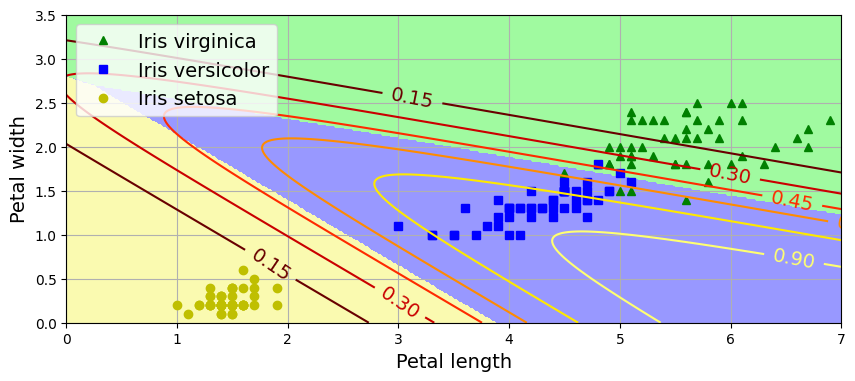

In [517]:
custom_cmap = mpl.colors.ListedColormap(['#fafab0', '#9898ff', '#a0faa0'])

x0, x1 = np.meshgrid(np.linspace(0, 8, 500).reshape(-1, 1),
                     np.linspace(0, 3.5, 200).reshape(-1, 1))
X_new = np.c_[x0.ravel(), x1.ravel()]
X_new = (X_new - mean) / std
X_new_with_bias = np.c_[np.ones(len(X_new)), X_new]

logits = X_new_with_bias @ Theta
Y_proba = softmax(logits)
y_predict = Y_proba.argmax(axis=1)

zz1 = Y_proba[:, 1].reshape(x0.shape)
zz = y_predict.reshape(x0.shape)

plt.figure(figsize=(10, 4))
plt.plot(X[y == 2, 0], X[y == 2, 1], "g^", label="Iris virginica")
plt.plot(X[y == 1, 0], X[y == 1, 1], "bs", label="Iris versicolor")
plt.plot(X[y == 0, 0], X[y == 0, 1], "yo", label="Iris setosa")

plt.contourf(x0, x1, zz, cmap=custom_cmap)
contour = plt.contour(x0, x1, zz1, cmap="hot")
plt.clabel(contour, inline=1)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="upper left")
plt.axis([0, 7, 0, 3.5])
plt.grid()
plt.show()

And now let's measure the final model's accuracy on the test set:

In [518]:
logits = X_test @ Theta
Y_proba = softmax(logits)
y_predict = Y_proba.argmax(axis=1)

accuracy_score = (y_predict == y_test).mean()
accuracy_score

0.9666666666666667

Well we get even better performance on the test set. This variability is likely due to the very small size of the dataset: depending on how you sample the training set, validation set and the test set, you can get quite different results. Try changing the random seed and running the code again a few times, you will see that the results will vary.